# 12 Literature Augmented Graph

## Цель этапа

Этот этап расширяет explainability-граф из `09_knowledge_graph_explainability.ipynb` дополнительными признаками, извлеченными из внешних агрономических источников, согласованных с географией исходного датасета USDA NASS CSB/CDL.

Важно зафиксировать границы интерпретации:

- новый literature-aware слой **не заменяет** CatBoost, не меняет shortlist-кандидатов и не меняет вероятности модели;
- новый слой **не превращает** работу в экспертный агрономический оптимизатор;
- литературные сигналы используются как **дополнительное support/warning evidence** поверх data-driven explainability из stage 09;
- `graph_support_score` на этом этапе пересчитывается только внутри explainability-слоя и сохраняется отдельно от базового score из `09`.


## Использованные внешние агрономические источники

На этом этапе российские, русскоязычные и узбекские источники были полностью удалены из literature-backed rule layer. В новой версии stage 12 правила опираются на американские и международные источники, лучше согласованные с тем, что исходный датасет проекта построен по USDA NASS CSB/CDL для США.

Эти источники используются только как **interpretation evidence**:

- они не меняют CatBoost-модель, shortlist-кандидатов, вероятности рекомендаций и ranking кандидатов;
- они не используются для переобучения модели и не меняют метрики CatBoost, Markov-1 или recommendation layer;
- они не трактуются как универсальные агрономические предписания и не превращают stage 12 в агрономический оптимизатор;
- часть правил применяется как `direct`, часть как `group_approx`, а `kluger_ditommaso_lobell_2025_precrop_effects` сохранен как methodological/context source без фиктивных transition rules;
- same-group saturation warning пропускается, если уже сработал exact repeat warning, чтобы не удваивать penalty за один и тот же смысл;
- повтор `forage_hay` трактуется как weak warning, потому что агрегированный forage/perennial/high-biomass класс может играть другую агрономическую роль, чем повтор annual row-crop;
- старые cotton-specific zonal rules удалены, потому что они не были согласованы с географией датасета по США.

1. **USDA Natural Resources Conservation Service. Conservation Practice Standard: Conservation Crop Rotation, Code 328. 2014.**
   - URL: `https://www.nrcs.usda.gov/sites/default/files/2022-09/Conservation_Crop_Rotation_328_CPS.pdf`
   - Использование: общий официальный источник по planned crop sequence, diversity, legume nitrogen credits, минимизации fallow и предупреждениям против повторения одной и той же культуры или семейства.

2. **Kluger, D. M., Owen, A. B., Lobell, D. B. Combining randomized field experiments with observational satellite data to assess the benefits of crop rotations on yields. arXiv:2112.13700, 2021.**
   - URL: `https://arxiv.org/abs/2112.13700`
   - Использование: direct support для `corn -> soybeans` и `soybeans -> corn` в американском corn-soy context, без трактовки как универсальной нормы для всех регионов и культур.

3. **Kluger, D. M., Di Tommaso, S., Lobell, D. B. Precrop Payoffs: Causal machine learning reveals large but variable yield benefits of crop rotation in major breadbaskets. 2025.**
   - URL: `https://arxiv.org/abs/2506.02384`
   - Использование: methodological/context note о том, что precrop effects зависят от crop sequence, погоды и локального контекста; источник не превращается в direct transition rule.

4. **Oklahoma State University Extension. Considerations When Rotating Wheat Behind Corn. 2017.**
   - URL: `https://extension.okstate.edu/fact-sheets/considerations-when-rotating-wheat-behind-corn.html`
   - Использование: caution warning для `corn -> wheat` из-за риска Fusarium head blight на corn residue; это именно caution signal, а не support rule или запрет.


In [5]:
from __future__ import annotations

import ast
import json
import re
from pathlib import Path

from IPython.display import Image as IPImage
from IPython.display import Markdown as IPMarkdown
from IPython.display import display as ipy_display
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_CWD = Path.cwd().resolve()
ROOT = None
for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]:
    if (candidate / "artifacts").exists() and (candidate / "notebooks").exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError(
        f"Could not resolve repository root from cwd={NOTEBOOK_CWD}. Expected a parent containing both 'artifacts' and 'notebooks'."
    )
print(f"Resolved repository root: {ROOT}")
BASE_RESULTS_DIR = ROOT / "artifacts" / "results" / "knowledge_graph_explainability"
RESULTS_DIR = ROOT / "artifacts" / "results" / "literature_graph"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CASE_EXPLANATIONS_PATH = BASE_RESULTS_DIR / "case_explanations.csv"
CASE_SUMMARY_PATH = BASE_RESULTS_DIR / "case_summary.csv"
KG_NODES_PATH = BASE_RESULTS_DIR / "kg_nodes.csv"
KG_EDGES_PATH = BASE_RESULTS_DIR / "kg_edges.csv"
KG_RULES_PATH = BASE_RESULTS_DIR / "kg_rules.csv"
TRANSITION_EDGES_PATH = BASE_RESULTS_DIR / "transition_edges.csv"
RUN_META_PATH = BASE_RESULTS_DIR / "run_meta.json"
LITERATURE_RULES_PATH = RESULTS_DIR / "literature_transition_rules.csv"
LITERATURE_SOURCES_PATH = RESULTS_DIR / "literature_sources.json"

REQUIRED_BASE_PATHS = [
    CASE_EXPLANATIONS_PATH,
    CASE_SUMMARY_PATH,
    KG_NODES_PATH,
    KG_EDGES_PATH,
    KG_RULES_PATH,
    TRANSITION_EDGES_PATH,
    RUN_META_PATH,
    LITERATURE_RULES_PATH,
]
missing_paths = [str(p) for p in REQUIRED_BASE_PATHS if not p.exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing required inputs: {missing_paths}")

CROP_TO_GROUP = {
    "corn": "cereal",
    "cotton": "industrial",
    "fallow": "fallow",
    "forage_hay": "forage",
    "legumes": "legume",
    "other_cereals": "cereal",
    "sorghum": "cereal",
    "soybeans": "legume",
    "wheat": "cereal",
}
ALLOWED_GROUPS = sorted({group_name for group_name in CROP_TO_GROUP.values() if pd.notna(group_name)})
ALLOWED_SIGNAL_TYPES = {"support", "warning"}
ALLOWED_STRENGTHS = {"weak", "medium", "strong"}
ALLOWED_MAPPING_LEVELS = {"direct", "group_approx", "context_note"}
LEGACY_SOURCE_IDS = {
    "stgau_rotation_basics",
    "kubsau_soy_predecessors",
    "wheat_predecessor_study",
    "cotton_irrigated_technology",
    "cotton_repeat_crop_study",
    "cotton_pest_rotation_uzbekistan",
}
FORBIDDEN_TEXT_FRAGMENTS = ("cyberleninka", "stgau", "kubsau", "узбек", "россий", "русскоязыч")


def normalize_signal_type(signal_type: str) -> str:
    signal_type = str(signal_type).strip().lower().replace(" ", "_")
    if signal_type in {"support", "good_predecessor", "return_interval", "acceptable_predecessor", "positive", "benefit"}:
        return "support"
    if signal_type in {"warning", "caution", "risk", "undesirable_predecessor", "negative"}:
        return "warning"
    raise ValueError(f"Unsupported signal_type: {signal_type}")


def is_valid_crop_token(value: str) -> bool:
    value = str(value).strip()
    if value in CROP_TO_GROUP:
        return True
    if value.startswith("group:"):
        return value.split(":", 1)[1] in ALLOWED_GROUPS
    return False


SOURCE_META = [
    {
        "source_id": "nrcs_conservation_crop_rotation_328",
        "short_label": "USDA NRCS CPS 328",
        "citation": "USDA Natural Resources Conservation Service. Conservation Practice Standard: Conservation Crop Rotation, Code 328. 2014.",
        "url": "https://www.nrcs.usda.gov/sites/default/files/2022-09/Conservation_Crop_Rotation_328_CPS.pdf",
        "coverage": [
            "general crop rotation diversity",
            "repeat crop caution",
            "group saturation warning",
            "legume nitrogen credit",
            "fallow minimization",
        ],
        "signal_types": ["support", "warning", "group_approx"],
    },
    {
        "source_id": "kluger_owen_lobell_2021_corn_soy_rotation",
        "short_label": "Kluger et al. 2021",
        "citation": "Kluger, D. M., Owen, A. B., Lobell, D. B. Combining randomized field experiments with observational satellite data to assess the benefits of crop rotations on yields. arXiv:2112.13700, 2021.",
        "url": "https://arxiv.org/abs/2112.13700",
        "coverage": ["corn -> soybeans", "soybeans -> corn", "Midwestern United States"],
        "signal_types": ["support", "direct"],
    },
    {
        "source_id": "kluger_ditommaso_lobell_2025_precrop_effects",
        "short_label": "Kluger et al. 2025",
        "citation": "Kluger, D. M., Di Tommaso, S., Lobell, D. B. Precrop Payoffs: Causal machine learning reveals large but variable yield benefits of crop rotation in major breadbaskets. arXiv:2506.02384, 2025.",
        "url": "https://arxiv.org/abs/2506.02384",
        "coverage": ["context dependence", "weather sensitivity", "major breadbaskets"],
        "signal_types": ["context_note"],
    },
    {
        "source_id": "fusarium_corn_residue_wheat_caution",
        "short_label": "OSU wheat-behind-corn caution",
        "citation": "Oklahoma State University Extension. Considerations When Rotating Wheat Behind Corn. 2017.",
        "url": "https://extension.okstate.edu/fact-sheets/considerations-when-rotating-wheat-behind-corn.html",
        "coverage": ["corn -> wheat", "Fusarium head blight caution", "residue-borne disease risk"],
        "signal_types": ["warning", "direct", "caution"],
    },
]
SOURCE_META_BY_ID = {meta["source_id"]: meta for meta in SOURCE_META}
if len(SOURCE_META_BY_ID) != len(SOURCE_META):
    raise ValueError("Duplicate source_id values detected in SOURCE_META.")
if sorted(SOURCE_META_BY_ID.keys() & LEGACY_SOURCE_IDS):
    raise ValueError("SOURCE_META still contains legacy source ids.")

source_meta_text_blob = json.dumps(SOURCE_META, ensure_ascii=False).lower()
found_forbidden_source_text = sorted({token for token in FORBIDDEN_TEXT_FRAGMENTS if token in source_meta_text_blob})
if found_forbidden_source_text:
    raise ValueError(f"SOURCE_META still contains forbidden legacy fragments: {found_forbidden_source_text}")

case_explanations_df = pd.read_csv(CASE_EXPLANATIONS_PATH)
case_summary_df = pd.read_csv(CASE_SUMMARY_PATH)
kg_nodes_df = pd.read_csv(KG_NODES_PATH)
kg_edges_df = pd.read_csv(KG_EDGES_PATH)
kg_rules_df = pd.read_csv(KG_RULES_PATH)
transition_edges_df = pd.read_csv(TRANSITION_EDGES_PATH)
literature_rules_df = pd.read_csv(LITERATURE_RULES_PATH).fillna("")
base_run_meta = json.loads(RUN_META_PATH.read_text(encoding="utf-8"))

required_case_cols = {
    "case_label", "candidate", "score", "candidate_rank", "is_model_top1", "is_true_target",
    "crop_group", "transition_prob", "region_share", "region_rank", "support_flags",
    "warning_flags", "graph_support_score", "graph_support_level", "short_explanation",
}
missing_case_cols = sorted(required_case_cols - set(case_explanations_df.columns))
if missing_case_cols:
    raise ValueError(f"case_explanations.csv is missing columns: {missing_case_cols}")

required_lit_cols = {
    "rule_id", "source_id", "source_title_short", "crop_context", "candidate", "signal_type",
    "strength", "mapping_level", "zonal_note", "evidence_text_short",
}
missing_lit_cols = sorted(required_lit_cols - set(literature_rules_df.columns))
if missing_lit_cols:
    raise ValueError(f"literature_transition_rules.csv is missing columns: {missing_lit_cols}")
if literature_rules_df["rule_id"].duplicated().any():
    duplicate_rule_ids = literature_rules_df.loc[literature_rules_df["rule_id"].duplicated(), "rule_id"].tolist()
    raise ValueError(f"Duplicate rule_id values found: {duplicate_rule_ids}")

literature_rules_df["source_id"] = literature_rules_df["source_id"].astype(str).str.strip()
literature_rules_df["crop_context"] = literature_rules_df["crop_context"].astype(str).str.strip()
literature_rules_df["candidate"] = literature_rules_df["candidate"].astype(str).str.strip()
literature_rules_df["signal_type"] = literature_rules_df["signal_type"].apply(normalize_signal_type)
literature_rules_df["strength"] = literature_rules_df["strength"].astype(str).str.strip().str.lower()
literature_rules_df["mapping_level"] = literature_rules_df["mapping_level"].astype(str).str.strip().str.lower()

unknown_source_ids = sorted(set(literature_rules_df["source_id"]) - set(SOURCE_META_BY_ID))
if unknown_source_ids:
    raise ValueError(f"literature_transition_rules.csv contains source_id values missing in SOURCE_META: {unknown_source_ids}")
legacy_rule_sources = sorted(set(literature_rules_df["source_id"]) & LEGACY_SOURCE_IDS)
if legacy_rule_sources:
    raise ValueError(f"literature_transition_rules.csv still contains legacy source ids: {legacy_rule_sources}")

invalid_contexts = sorted({value for value in literature_rules_df["crop_context"] if not is_valid_crop_token(value)})
invalid_candidates = sorted({value for value in literature_rules_df["candidate"] if not is_valid_crop_token(value)})
if invalid_contexts:
    raise ValueError(f"Invalid crop_context values in literature_transition_rules.csv: {invalid_contexts}")
if invalid_candidates:
    raise ValueError(f"Invalid candidate values in literature_transition_rules.csv: {invalid_candidates}")

invalid_signal_types = sorted(set(literature_rules_df["signal_type"]) - ALLOWED_SIGNAL_TYPES)
invalid_strengths = sorted(set(literature_rules_df["strength"]) - ALLOWED_STRENGTHS)
invalid_mapping_levels = sorted(set(literature_rules_df["mapping_level"]) - ALLOWED_MAPPING_LEVELS)
if invalid_signal_types:
    raise ValueError(f"Unexpected signal_type values after normalization: {invalid_signal_types}")
if invalid_strengths:
    raise ValueError(f"Unexpected strength values: {invalid_strengths}")
if invalid_mapping_levels:
    raise ValueError(f"Unexpected mapping_level values: {invalid_mapping_levels}")

rule_text_columns = ["rule_id", "source_id", "source_title_short", "crop_context", "candidate", "zonal_note", "evidence_text_short"]
rules_text_blob = " ".join(
    " ".join(str(value) for value in literature_rules_df.loc[idx, rule_text_columns].tolist())
    for idx in literature_rules_df.index
).lower()
found_forbidden_rule_text = sorted({token for token in FORBIDDEN_TEXT_FRAGMENTS if token in rules_text_blob})
if found_forbidden_rule_text:
    raise ValueError(f"literature_transition_rules.csv still contains forbidden legacy fragments: {found_forbidden_rule_text}")

forbidden_cotton_rows = literature_rules_df[
    (
        (literature_rules_df["crop_context"] == "legumes")
        & (literature_rules_df["candidate"] == "cotton")
        & (literature_rules_df["signal_type"] == "support")
    )
    | (
        (literature_rules_df["crop_context"] == "forage_hay")
        & (literature_rules_df["candidate"] == "cotton")
        & (literature_rules_df["signal_type"] == "support")
    )
    | (
        (literature_rules_df["crop_context"] == "wheat")
        & (literature_rules_df["candidate"] == "cotton")
        & (literature_rules_df["signal_type"] == "warning")
    )
]
if not forbidden_cotton_rows.empty:
    raise ValueError("Found forbidden legacy cotton-specific zonal rules in literature_transition_rules.csv.")

forbidden_cotton_id_fragments = ("uzbek", "irrigated", "pest_rotation", "cotton_irrigated", "cotton_pest")
cotton_id_blob = " ".join(literature_rules_df["rule_id"].astype(str).tolist() + literature_rules_df["source_id"].astype(str).tolist()).lower()
found_forbidden_cotton_ids = sorted({token for token in forbidden_cotton_id_fragments if token in cotton_id_blob})
if found_forbidden_cotton_ids:
    raise ValueError(f"Found forbidden cotton-specific id fragments: {found_forbidden_cotton_ids}")

if "Environmental Research Letters" in SOURCE_META_BY_ID["kluger_owen_lobell_2021_corn_soy_rotation"]["citation"]:
    raise ValueError("Kluger 2021 citation still contains unsupported journal claim.")

if "wikipedia" in SOURCE_META_BY_ID["fusarium_corn_residue_wheat_caution"]["url"].lower():
    raise ValueError("Fusarium caution source must not be Wikipedia.")

fhb_rule_df = literature_rules_df.loc[literature_rules_df["rule_id"] == "fhb_corn_to_wheat_caution"]
if len(fhb_rule_df) != 1:
    raise ValueError("Expected exactly one fhb_corn_to_wheat_caution rule.")
fhb_rule = fhb_rule_df.iloc[0].to_dict()
if not (
    fhb_rule["source_id"] == "fusarium_corn_residue_wheat_caution"
    and fhb_rule["crop_context"] == "corn"
    and fhb_rule["candidate"] == "wheat"
    and fhb_rule["signal_type"] == "warning"
    and fhb_rule["mapping_level"] == "direct"
    and fhb_rule["strength"] in {"weak", "medium"}
):
    raise ValueError("FHB corn->wheat caution rule contract is invalid.")

with LITERATURE_SOURCES_PATH.open("w", encoding="utf-8") as f:
    json.dump(SOURCE_META, f, ensure_ascii=False, indent=2)

print("Loaded base case rows:", len(case_explanations_df))
print("Loaded base cases:", case_explanations_df["case_label"].nunique())
print("Loaded literature rules:", len(literature_rules_df))
print("Loaded literature sources:", len(SOURCE_META))
display(
    literature_rules_df[
        ["source_id", "rule_id", "crop_context", "candidate", "signal_type", "strength", "mapping_level"]
    ].sort_values(["source_id", "rule_id"]).reset_index(drop=True)
)


Resolved repository root: C:\Users\Dmitry\code-projects\diploma-crop-rotation
Loaded base case rows: 12
Loaded base cases: 4
Loaded literature rules: 32
Loaded literature sources: 4


,source_id,rule_id,crop_context,candidate,signal_type,strength,mapping_level
0,fusarium_corn_residue_wheat_caution,fhb_corn_to_wheat_caution,corn,wheat,warning,medium,direct
1,kluger_owen_lobell_2021_corn_soy_rotation,kluger_corn_to_soybeans_support,corn,soybeans,support,strong,direct
2,kluger_owen_lobell_2021_corn_soy_rotation,kluger_soybeans_to_corn_support,soybeans,corn,support,strong,direct
3,nrcs_conservation_crop_rotation_328,nrcs_fallow_repeat_warning,fallow,fallow,warning,strong,direct
4,nrcs_conservation_crop_rotation_328,nrcs_fallow_to_crop_support_corn,fallow,corn,support,weak,direct
5,nrcs_conservation_crop_rotation_328,nrcs_fallow_to_crop_support_forage_hay,fallow,forage_hay,support,weak,direct
6,nrcs_conservation_crop_rotation_328,nrcs_fallow_to_crop_support_legumes,fallow,legumes,support,weak,direct
7,nrcs_conservation_crop_rotation_328,nrcs_fallow_to_crop_support_other_cereals,fallow,other_cereals,support,weak,direct
8,nrcs_conservation_crop_rotation_328,nrcs_fallow_to_crop_support_sorghum,fallow,sorghum,support,weak,direct
9,nrcs_conservation_crop_rotation_328,nrcs_fallow_to_crop_support_soybeans,fallow,soybeans,support,weak,direct


In [6]:
GRAPH_SCORE_WEIGHTS = {
    "transition": 0.50,
    "region_share": 0.30,
    "region_rank": 0.10,
    "support_bonus": 0.04,
    "warning_penalty": 0.05,
}
GRAPH_ALIGNMENT_MARGIN = 0.08
LITERATURE_STRENGTH_WEIGHTS = {"weak": 0.01, "medium": 0.02, "strong": 0.03}


def parse_listlike(value):
    if isinstance(value, list):
        return value
    if pd.isna(value) or value == "":
        return []
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []


def extract_last_crop(text: str) -> str | None:
    if pd.isna(text):
        return None
    m = re.search(r"Observed transition\s+([a-z_]+)\s*->\s*([a-z_]+)", str(text))
    return m.group(1) if m else None


def match_context(context_value: str, crop_name: str, crop_group: str) -> bool:
    if not isinstance(context_value, str) or not context_value:
        return False
    if context_value.startswith("group:"):
        return crop_group == context_value.split(":", 1)[1]
    return crop_name == context_value


def is_same_group_saturation_warning(rule: dict) -> bool:
    return "same_group_saturation" in str(rule["rule_id"])


def is_direct_repeat_warning(rule: dict, last_crop: str, candidate: str) -> bool:
    return (
        normalize_signal_type(rule["signal_type"]) == "warning"
        and ("repeat_crop_warning" in str(rule["rule_id"]) or str(rule["mapping_level"]).lower() == "direct")
        and str(last_crop) == str(candidate)
        and str(rule["crop_context"]) == str(candidate)
        and str(rule["candidate"]) == str(candidate)
    )


def compute_graph_support_score(transition_prob, region_share, region_rank, support_flags, warning_flags):
    transition_norm = 0.0 if pd.isna(transition_prob) else float(np.clip(float(transition_prob), 0.0, 1.0))
    region_norm = 0.0 if pd.isna(region_share) else float(np.clip(float(region_share), 0.0, 1.0))
    if pd.isna(region_rank):
        region_rank_norm = 0.0
    else:
        region_rank_norm = float(np.clip((4.0 - float(region_rank)) / 3.0, 0.0, 1.0))
    support_bonus = GRAPH_SCORE_WEIGHTS["support_bonus"] * min(len(support_flags), 3)
    warning_penalty = GRAPH_SCORE_WEIGHTS["warning_penalty"] * min(len(warning_flags), 3)
    score = (
        GRAPH_SCORE_WEIGHTS["transition"] * transition_norm
        + GRAPH_SCORE_WEIGHTS["region_share"] * region_norm
        + GRAPH_SCORE_WEIGHTS["region_rank"] * region_rank_norm
        + support_bonus
        - warning_penalty
    )
    return float(np.clip(score, 0.0, 1.0))


def resolve_graph_support_level(score: float) -> str:
    if score >= 0.66:
        return "strong"
    if score >= 0.33:
        return "moderate"
    return "weak"


def compute_alignment(df: pd.DataFrame, score_col: str, margin: float = GRAPH_ALIGNMENT_MARGIN) -> str:
    if df.empty:
        return "weak"
    top1_row = df[df["is_model_top1"]].head(1)
    if top1_row.empty:
        return "weak"
    top1_score = float(top1_row[score_col].iloc[0])
    best_score = float(df[score_col].max())
    alt_df = df[~df["is_model_top1"]]
    best_alt_score = float(alt_df[score_col].max()) if not alt_df.empty else top1_score
    if top1_score >= best_score - 1e-9:
        return "strong"
    if (best_alt_score - top1_score) <= float(margin):
        return "medium"
    return "weak"


case_aug_df = case_explanations_df.copy()
case_aug_df["support_flags"] = case_aug_df["support_flags"].apply(parse_listlike)
case_aug_df["warning_flags"] = case_aug_df["warning_flags"].apply(parse_listlike)
case_aug_df["last_crop"] = case_aug_df["short_explanation"].apply(extract_last_crop)
case_aug_df["last_crop_group"] = case_aug_df["last_crop"].map(CROP_TO_GROUP)
case_aug_df["candidate_group_mapped"] = case_aug_df["candidate"].map(CROP_TO_GROUP).fillna(case_aug_df["crop_group"])
case_aug_df["base_graph_support_score"] = case_aug_df["graph_support_score"].astype(float)
case_aug_df["base_graph_support_level"] = case_aug_df["graph_support_level"]

aug_rows = []
exact_repeat_candidate_rows_count = 0
skipped_same_group_saturation_due_to_exact_repeat_warning_count = 0
total_triggered_rule_hits_count = 0

for row in case_aug_df.to_dict(orient="records"):
    matched_rules = []
    for _, lit_rule in literature_rules_df.iterrows():
        crop_match = match_context(str(lit_rule["crop_context"]), str(row["last_crop"]), str(row["last_crop_group"]))
        cand_match = match_context(str(lit_rule["candidate"]), str(row["candidate"]), str(row["candidate_group_mapped"]))
        if crop_match and cand_match:
            matched_rules.append(lit_rule.to_dict())

    is_exact_repeat_candidate_row = str(row["last_crop"]) == str(row["candidate"])
    if is_exact_repeat_candidate_row:
        exact_repeat_candidate_rows_count += 1

    direct_repeat_warning_rules = [
        rule for rule in matched_rules
        if is_direct_repeat_warning(rule, str(row["last_crop"]), str(row["candidate"]))
    ]
    skipped_same_group_saturation_rules = []
    if direct_repeat_warning_rules:
        # Avoid double-counting exact repeat and same-group saturation warnings: exact crop repetition is treated as a more specific signal.
        filtered_rules = []
        for rule in matched_rules:
            if is_same_group_saturation_warning(rule):
                skipped_same_group_saturation_rules.append(rule)
                continue
            filtered_rules.append(rule)
        matched_rules = filtered_rules
        skipped_same_group_saturation_due_to_exact_repeat_warning_count += len(skipped_same_group_saturation_rules)

    literature_support_rules = [r for r in matched_rules if normalize_signal_type(r["signal_type"]) == "support"]
    literature_warning_rules = [r for r in matched_rules if normalize_signal_type(r["signal_type"]) == "warning"]
    literature_support_flags = [r["rule_id"] for r in literature_support_rules]
    literature_warning_flags = [r["rule_id"] for r in literature_warning_rules]
    matched_rule_ids = sorted({r["rule_id"] for r in matched_rules})

    combined_support_flags = list(row["support_flags"]) + literature_support_flags
    combined_warning_flags = list(row["warning_flags"]) + literature_warning_flags

    literature_strength_bonus = sum(LITERATURE_STRENGTH_WEIGHTS.get(str(r["strength"]).lower(), 0.0) for r in literature_support_rules)
    literature_strength_penalty = sum(LITERATURE_STRENGTH_WEIGHTS.get(str(r["strength"]).lower(), 0.0) for r in literature_warning_rules)

    literature_graph_support_score = compute_graph_support_score(
        row["transition_prob"],
        row["region_share"],
        row["region_rank"],
        combined_support_flags,
        combined_warning_flags,
    )
    literature_graph_support_score = float(np.clip(
        literature_graph_support_score + literature_strength_bonus - literature_strength_penalty,
        0.0,
        1.0,
    ))

    total_triggered_rule_hits_count += len(matched_rules)
    literature_evidence_bits = [
        f"[{r['source_id']}] {r['evidence_text_short']}"
        for r in matched_rules
    ]
    row["literature_support_flags"] = literature_support_flags
    row["literature_warning_flags"] = literature_warning_flags
    row["combined_support_flags"] = combined_support_flags
    row["combined_warning_flags"] = combined_warning_flags
    row["literature_strength_bonus"] = literature_strength_bonus
    row["literature_strength_penalty"] = literature_strength_penalty
    row["n_literature_rules_matched"] = len(matched_rules)
    row["matched_literature_rule_ids"] = matched_rule_ids
    row["is_exact_repeat_candidate_row"] = bool(is_exact_repeat_candidate_row)
    row["has_direct_repeat_warning"] = bool(direct_repeat_warning_rules)
    row["direct_repeat_warning_rule_ids"] = [rule["rule_id"] for rule in direct_repeat_warning_rules]
    row["skipped_same_group_saturation_rule_ids"] = [rule["rule_id"] for rule in skipped_same_group_saturation_rules]
    row["literature_graph_support_score"] = literature_graph_support_score
    row["literature_graph_support_level"] = resolve_graph_support_level(literature_graph_support_score)
    row["delta_graph_support_score"] = literature_graph_support_score - float(row["base_graph_support_score"])
    row["literature_evidence_summary"] = " ".join(literature_evidence_bits)
    row["literature_short_explanation"] = (
        str(row["short_explanation"])
        + (" Literature-backed evidence: " + " ".join(literature_evidence_bits) if literature_evidence_bits else "")
    )
    aug_rows.append(row)

literature_augmented_case_explanations_df = pd.DataFrame(aug_rows)

double_count_violation_df = literature_augmented_case_explanations_df[
    literature_augmented_case_explanations_df["has_direct_repeat_warning"]
    & literature_augmented_case_explanations_df["literature_warning_flags"].apply(
        lambda flags: any("same_group_saturation" in str(flag) for flag in flags)
    )
]
if not double_count_violation_df.empty:
    raise ValueError("Exact repeat rows still contain same_group_saturation warnings after filtering.")

summary_rows = []
for case_label, cdf in literature_augmented_case_explanations_df.groupby("case_label", sort=False):
    cdf = cdf.sort_values(["candidate_rank", "score"])
    top1_row = cdf[cdf["is_model_top1"]].iloc[0]
    best_lit_row = cdf.sort_values(["literature_graph_support_score", "score"], ascending=[False, False]).iloc[0]
    literature_alignment = compute_alignment(cdf, "literature_graph_support_score")
    base_alignment = str(cdf["top1_graph_alignment"].iloc[0])
    triggered_rules = sorted(set(sum(cdf["literature_support_flags"].tolist(), []) + sum(cdf["literature_warning_flags"].tolist(), [])))
    alignment_transition = f"{base_alignment} -> {literature_alignment}"
    summary_rows.append({
        "case_label": case_label,
        "target": cdf["candidate"].loc[cdf["is_true_target"]].iloc[0] if cdf["is_true_target"].any() else None,
        "model_top1": top1_row["candidate"],
        "base_top1_graph_support_score": float(top1_row["base_graph_support_score"]),
        "literature_top1_graph_support_score": float(top1_row["literature_graph_support_score"]),
        "base_top1_graph_alignment": base_alignment,
        "literature_top1_graph_alignment": literature_alignment,
        "alignment_transition": alignment_transition,
        "alignment_changed": bool(base_alignment != literature_alignment),
        "best_literature_candidate": best_lit_row["candidate"],
        "best_literature_graph_support_score": float(best_lit_row["literature_graph_support_score"]),
        "graph_support_gap_best_minus_top1_literature": float(best_lit_row["literature_graph_support_score"] - top1_row["literature_graph_support_score"]),
        "n_triggered_literature_rules": len(triggered_rules),
        "triggered_literature_rules": triggered_rules,
        "case_literature_summary": (
            f"Base alignment={base_alignment}, literature alignment={literature_alignment}. "
            f"Top-1 {top1_row['candidate']} changed by {float(top1_row['delta_graph_support_score']):+.3f}. "
            f"Best literature-supported candidate is {best_lit_row['candidate']} (gs={float(best_lit_row['literature_graph_support_score']):.3f})."
        ),
    })

literature_augmented_case_summary_df = pd.DataFrame(summary_rows)

comparison_df = literature_augmented_case_explanations_df[
    [
        "case_label",
        "candidate",
        "candidate_rank",
        "is_model_top1",
        "is_true_target",
        "base_graph_support_score",
        "base_graph_support_level",
        "literature_graph_support_score",
        "literature_graph_support_level",
        "delta_graph_support_score",
        "top1_graph_alignment",
        "literature_support_flags",
        "literature_warning_flags",
        "n_literature_rules_matched",
        "matched_literature_rule_ids",
        "is_exact_repeat_candidate_row",
        "has_direct_repeat_warning",
        "direct_repeat_warning_rule_ids",
        "skipped_same_group_saturation_rule_ids",
        "literature_evidence_summary",
    ]
].copy()

triggered_rule_ids_unique = sorted(
    set(sum(literature_augmented_case_explanations_df["literature_support_flags"].tolist(), []))
    | set(sum(literature_augmented_case_explanations_df["literature_warning_flags"].tolist(), []))
)
run_summary_df = pd.DataFrame(
    [
        {
            "literature_sources_count": int(len(SOURCE_META)),
            "literature_rules_count": int(len(literature_rules_df)),
            "triggered_rules_across_4_cases_count": int(len(triggered_rule_ids_unique)),
            "total_triggered_rule_hits_count": int(total_triggered_rule_hits_count),
            "exact_repeat_candidate_rows_count": int(exact_repeat_candidate_rows_count),
            "skipped_same_group_saturation_due_to_exact_repeat_warning_count": int(skipped_same_group_saturation_due_to_exact_repeat_warning_count),
            "mean_delta_graph_support_score_all_candidate_rows": float(comparison_df["delta_graph_support_score"].mean()),
            "mean_delta_graph_support_score_model_top1_rows": float(comparison_df.loc[comparison_df["is_model_top1"], "delta_graph_support_score"].mean()),
            "mean_delta_graph_support_score_non_top1_rows": float(comparison_df.loc[~comparison_df["is_model_top1"], "delta_graph_support_score"].mean()),
            "cases_with_changed_alignment_category_count": int(literature_augmented_case_summary_df["alignment_changed"].sum()),
        }
    ]
)

print("Machine-readable run summary:")
display(run_summary_df)
display(literature_augmented_case_summary_df)
display(comparison_df)


Machine-readable run summary:


,literature_sources_count,literature_rules_count,triggered_rules_across_4_cases_count,total_triggered_rule_hits_count,exact_repeat_candidate_rows_count,skipped_same_group_saturation_due_to_exact_repeat_warning_count,mean_delta_graph_support_score_all_candidate_rows,mean_delta_graph_support_score_model_top1_rows,mean_delta_graph_support_score_non_top1_rows,cases_with_changed_alignment_category_count
0,4,32,7,9,3,3,0.008333,-0.02,0.0225,0


,case_label,target,model_top1,base_top1_graph_support_score,literature_top1_graph_support_score,base_top1_graph_alignment,literature_top1_graph_alignment,alignment_transition,alignment_changed,best_literature_candidate,best_literature_graph_support_score,graph_support_gap_best_minus_top1_literature,n_triggered_literature_rules,triggered_literature_rules,case_literature_summary
0,case_high_confidence,forage_hay,forage_hay,0.660545,0.600545,strong,strong,strong -> strong,False,forage_hay,0.600545,0.000000,1,[nrcs_repeat_crop_warning_forage_hay],"Base alignment=strong, literature alignment=st..."
1,case_medium_confidence,corn,corn,0.375989,0.305989,weak,weak,weak -> weak,False,soybeans,0.588123,0.282135,3,"[kluger_corn_to_soybeans_support, nrcs_legume_...","Base alignment=weak, literature alignment=weak..."
2,case_low_confidence,legumes,legumes,0.010571,0.060571,weak,weak,weak -> weak,False,soybeans,0.688460,0.627889,3,"[kluger_corn_to_soybeans_support, nrcs_legume_...","Base alignment=weak, literature alignment=weak..."
3,case_difficult_class,soybeans,corn,0.219969,0.219969,weak,weak,weak -> weak,False,soybeans,0.436288,0.216319,2,[nrcs_legume_break_bonus_soybeans_after_indust...,"Base alignment=weak, literature alignment=weak..."


,case_label,candidate,candidate_rank,is_model_top1,is_true_target,base_graph_support_score,base_graph_support_level,literature_graph_support_score,literature_graph_support_level,delta_graph_support_score,top1_graph_alignment,literature_support_flags,literature_warning_flags,n_literature_rules_matched,matched_literature_rule_ids,is_exact_repeat_candidate_row,has_direct_repeat_warning,direct_repeat_warning_rule_ids,skipped_same_group_saturation_rule_ids,literature_evidence_summary
0,case_high_confidence,forage_hay,1,True,True,0.660545,strong,0.600545,moderate,-6.000000e-02,strong,[],[nrcs_repeat_crop_warning_forage_hay],1,[nrcs_repeat_crop_warning_forage_hay],True,True,[nrcs_repeat_crop_warning_forage_hay],[nrcs_same_group_saturation_warning_forage],[nrcs_conservation_crop_rotation_328] NRCS CPS...
1,case_high_confidence,corn,2,False,False,0.067884,weak,0.067884,weak,2.775558e-17,strong,[],[],0,[],False,False,[],[],
2,case_high_confidence,wheat,3,False,False,0.135650,weak,0.135650,weak,5.551115e-17,strong,[],[],0,[],False,False,[],[],
3,case_medium_confidence,corn,1,True,True,0.375989,moderate,0.305989,weak,-7.000000e-02,weak,[],[nrcs_repeat_crop_warning_corn],1,[nrcs_repeat_crop_warning_corn],True,True,[nrcs_repeat_crop_warning_corn],[nrcs_same_group_saturation_warning_cereal],[nrcs_conservation_crop_rotation_328] NRCS CPS...
4,case_medium_confidence,soybeans,2,False,False,0.508123,moderate,0.588123,moderate,8.000000e-02,weak,[nrcs_legume_break_bonus_soybeans_after_cereal...,[],2,"[kluger_corn_to_soybeans_support, nrcs_legume_...",False,False,[],[],[nrcs_conservation_crop_rotation_328] NRCS CPS...
5,case_medium_confidence,forage_hay,3,False,False,0.148390,weak,0.148390,weak,-5.551115e-17,weak,[],[],0,[],False,False,[],[],
6,case_low_confidence,legumes,1,True,True,0.010571,weak,0.060571,weak,5.000000e-02,weak,[nrcs_legume_break_bonus_legumes_after_cereal],[],1,[nrcs_legume_break_bonus_legumes_after_cereal],False,False,[],[],[nrcs_conservation_crop_rotation_328] NRCS CPS...
7,case_low_confidence,soybeans,2,False,False,0.568460,moderate,0.688460,strong,1.200000e-01,weak,[nrcs_legume_break_bonus_soybeans_after_cereal...,[],2,"[kluger_corn_to_soybeans_support, nrcs_legume_...",False,False,[],[],[nrcs_conservation_crop_rotation_328] NRCS CPS...
8,case_low_confidence,fallow,3,False,False,0.125709,weak,0.125709,weak,0.000000e+00,weak,[],[],0,[],False,False,[],[],
9,case_difficult_class,corn,1,True,False,0.219969,weak,0.219969,weak,-5.551115e-17,weak,[],[],0,[],False,False,[],[],


Saved literature-aware outputs to: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph


,case_label,target,model_top1,base_top1_graph_support_score,literature_top1_graph_support_score,base_top1_graph_alignment,literature_top1_graph_alignment,alignment_transition,alignment_changed,best_literature_candidate,best_literature_graph_support_score,graph_support_gap_best_minus_top1_literature,n_triggered_literature_rules,triggered_literature_rules,case_literature_summary
0,case_high_confidence,forage_hay,forage_hay,0.660545,0.600545,strong,strong,strong -> strong,False,forage_hay,0.600545,0.000000,1,[nrcs_repeat_crop_warning_forage_hay],"Base alignment=strong, literature alignment=st..."
1,case_medium_confidence,corn,corn,0.375989,0.305989,weak,weak,weak -> weak,False,soybeans,0.588123,0.282135,3,"[kluger_corn_to_soybeans_support, nrcs_legume_...","Base alignment=weak, literature alignment=weak..."
2,case_low_confidence,legumes,legumes,0.010571,0.060571,weak,weak,weak -> weak,False,soybeans,0.688460,0.627889,3,"[kluger_corn_to_soybeans_support, nrcs_legume_...","Base alignment=weak, literature alignment=weak..."
3,case_difficult_class,soybeans,corn,0.219969,0.219969,weak,weak,weak -> weak,False,soybeans,0.436288,0.216319,2,[nrcs_legume_break_bonus_soybeans_after_indust...,"Base alignment=weak, literature alignment=weak..."


Machine-readable run summary (persisted in run_meta.json):


,literature_sources_count,literature_rules_count,triggered_rules_across_4_cases_count,total_triggered_rule_hits_count,exact_repeat_candidate_rows_count,skipped_same_group_saturation_due_to_exact_repeat_warning_count,mean_delta_graph_support_score_all_candidate_rows,mean_delta_graph_support_score_model_top1_rows,mean_delta_graph_support_score_non_top1_rows,cases_with_changed_alignment_category_count
0,4,32,7,9,3,3,0.008333,-0.02,0.0225,0


Inline case-study figures:
- case_high_confidence: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_high_confidence_literature_graph.png


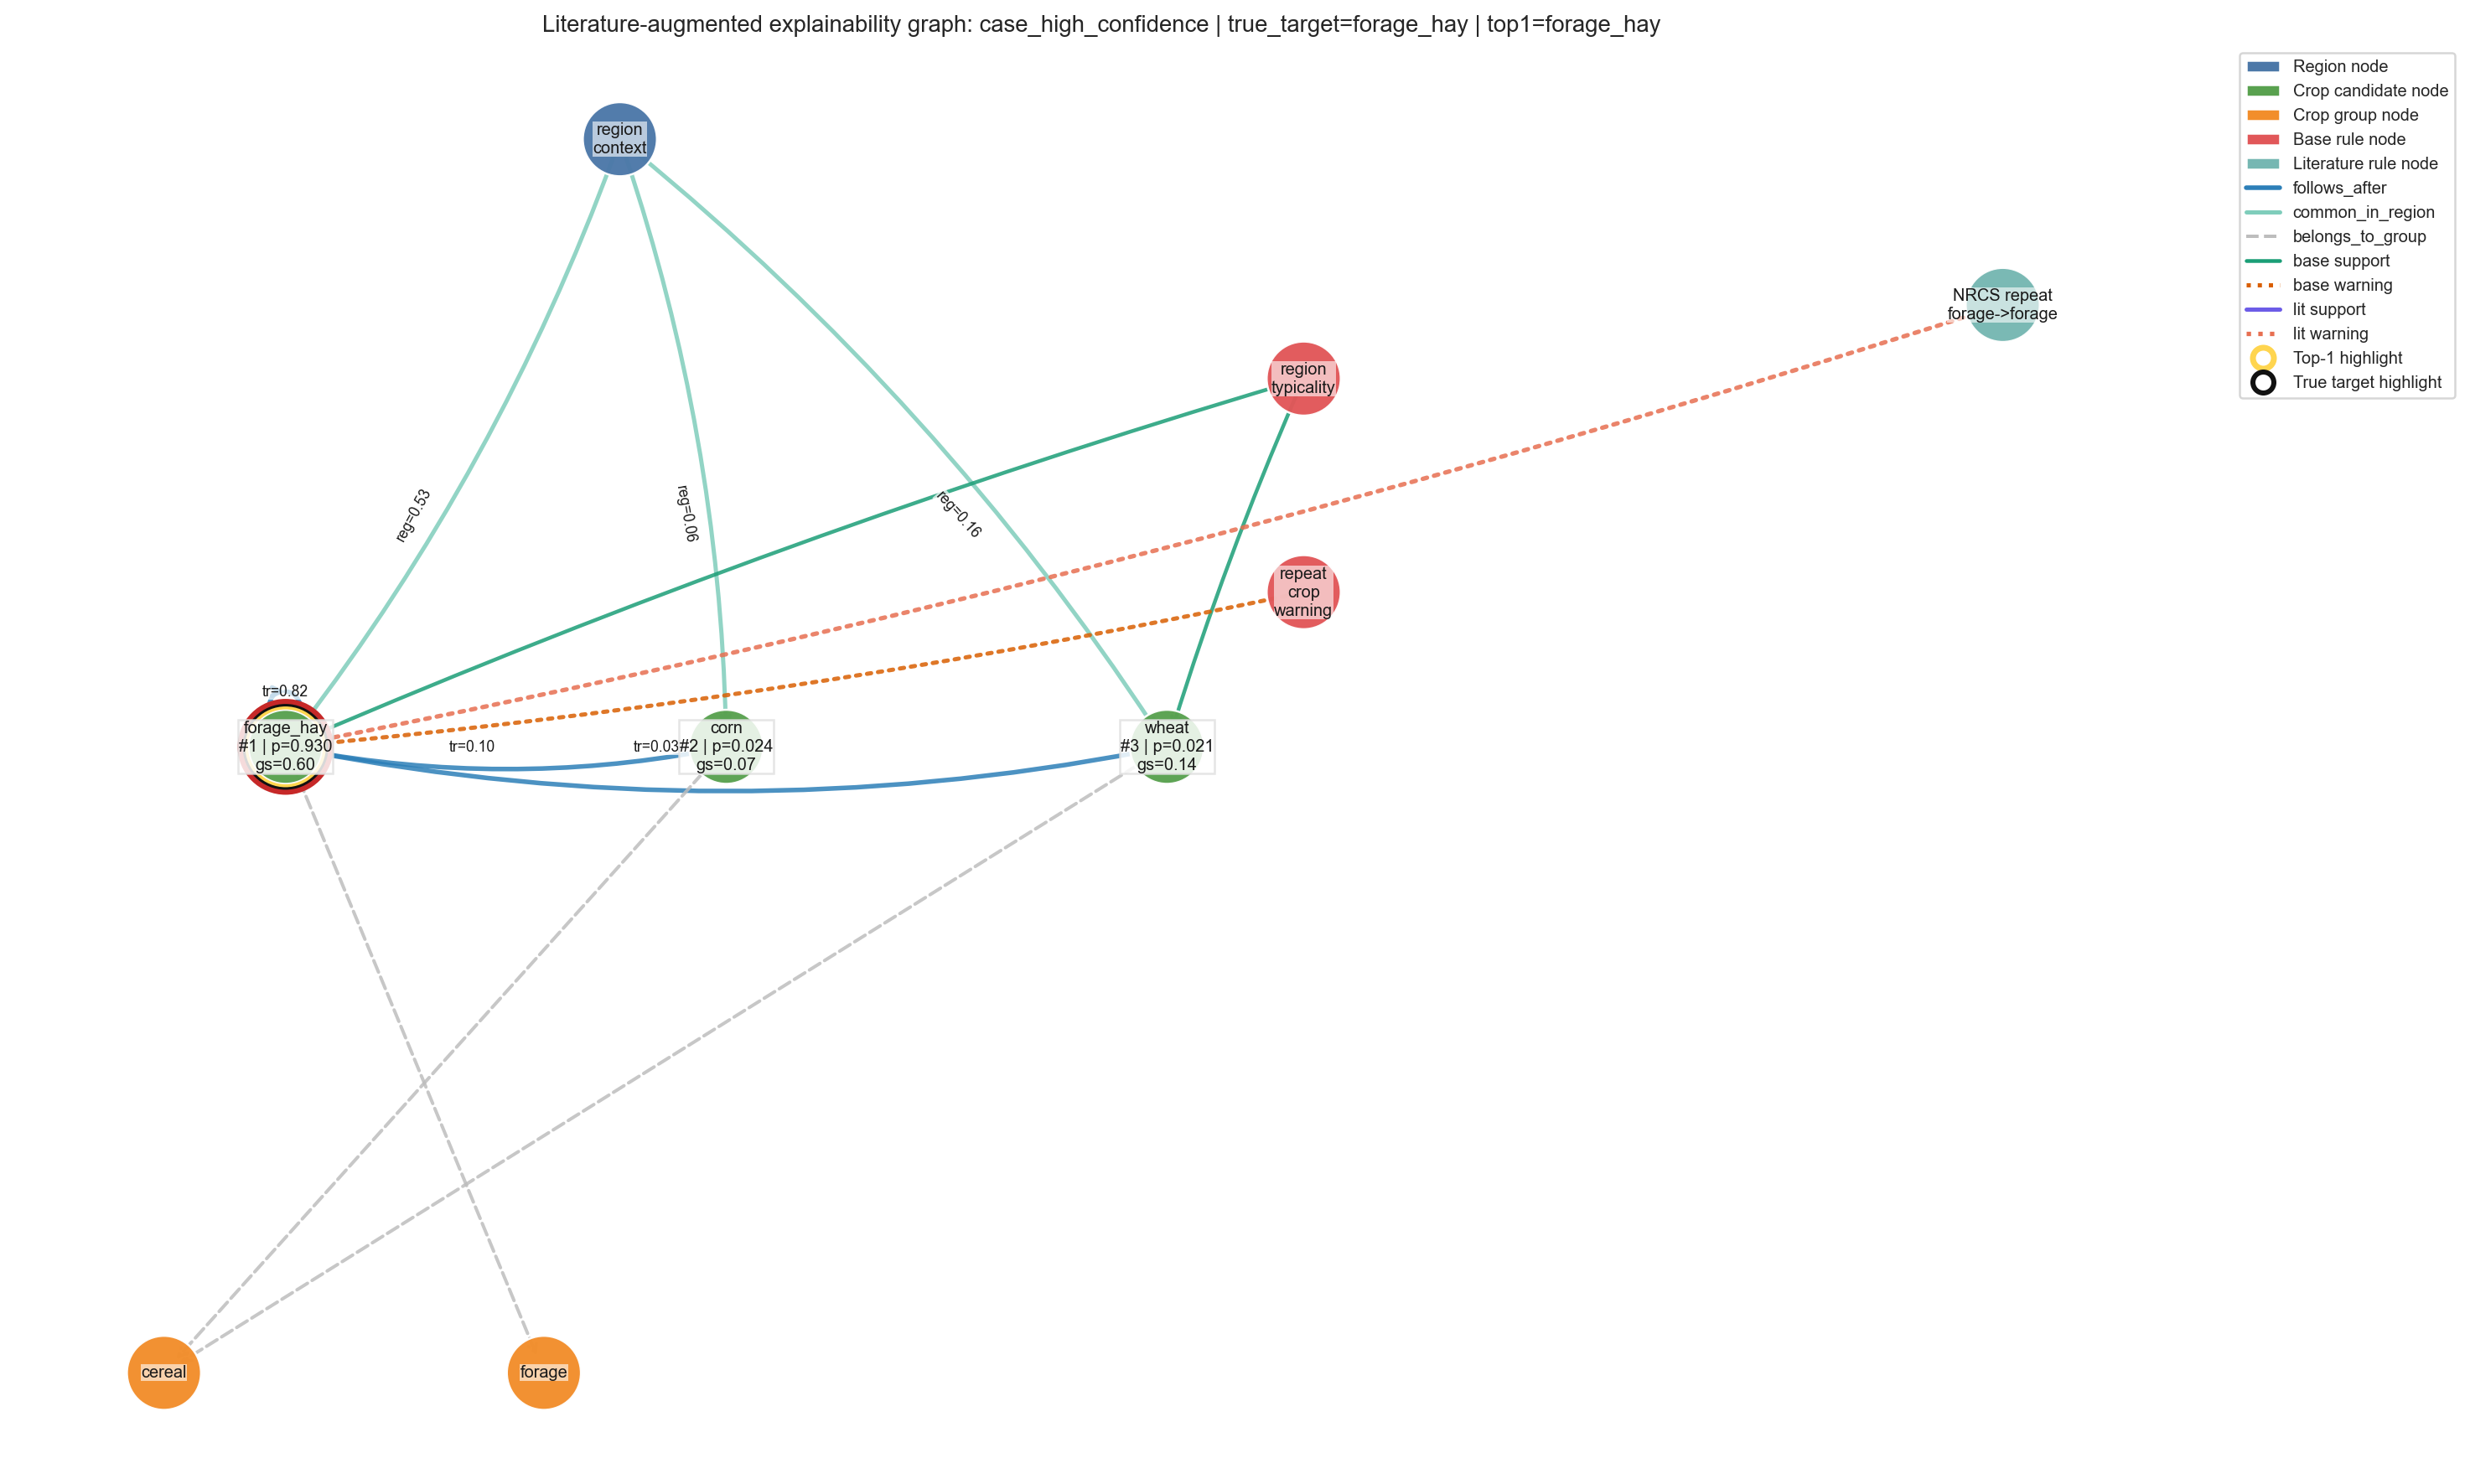

- case_medium_confidence: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_medium_confidence_literature_graph.png


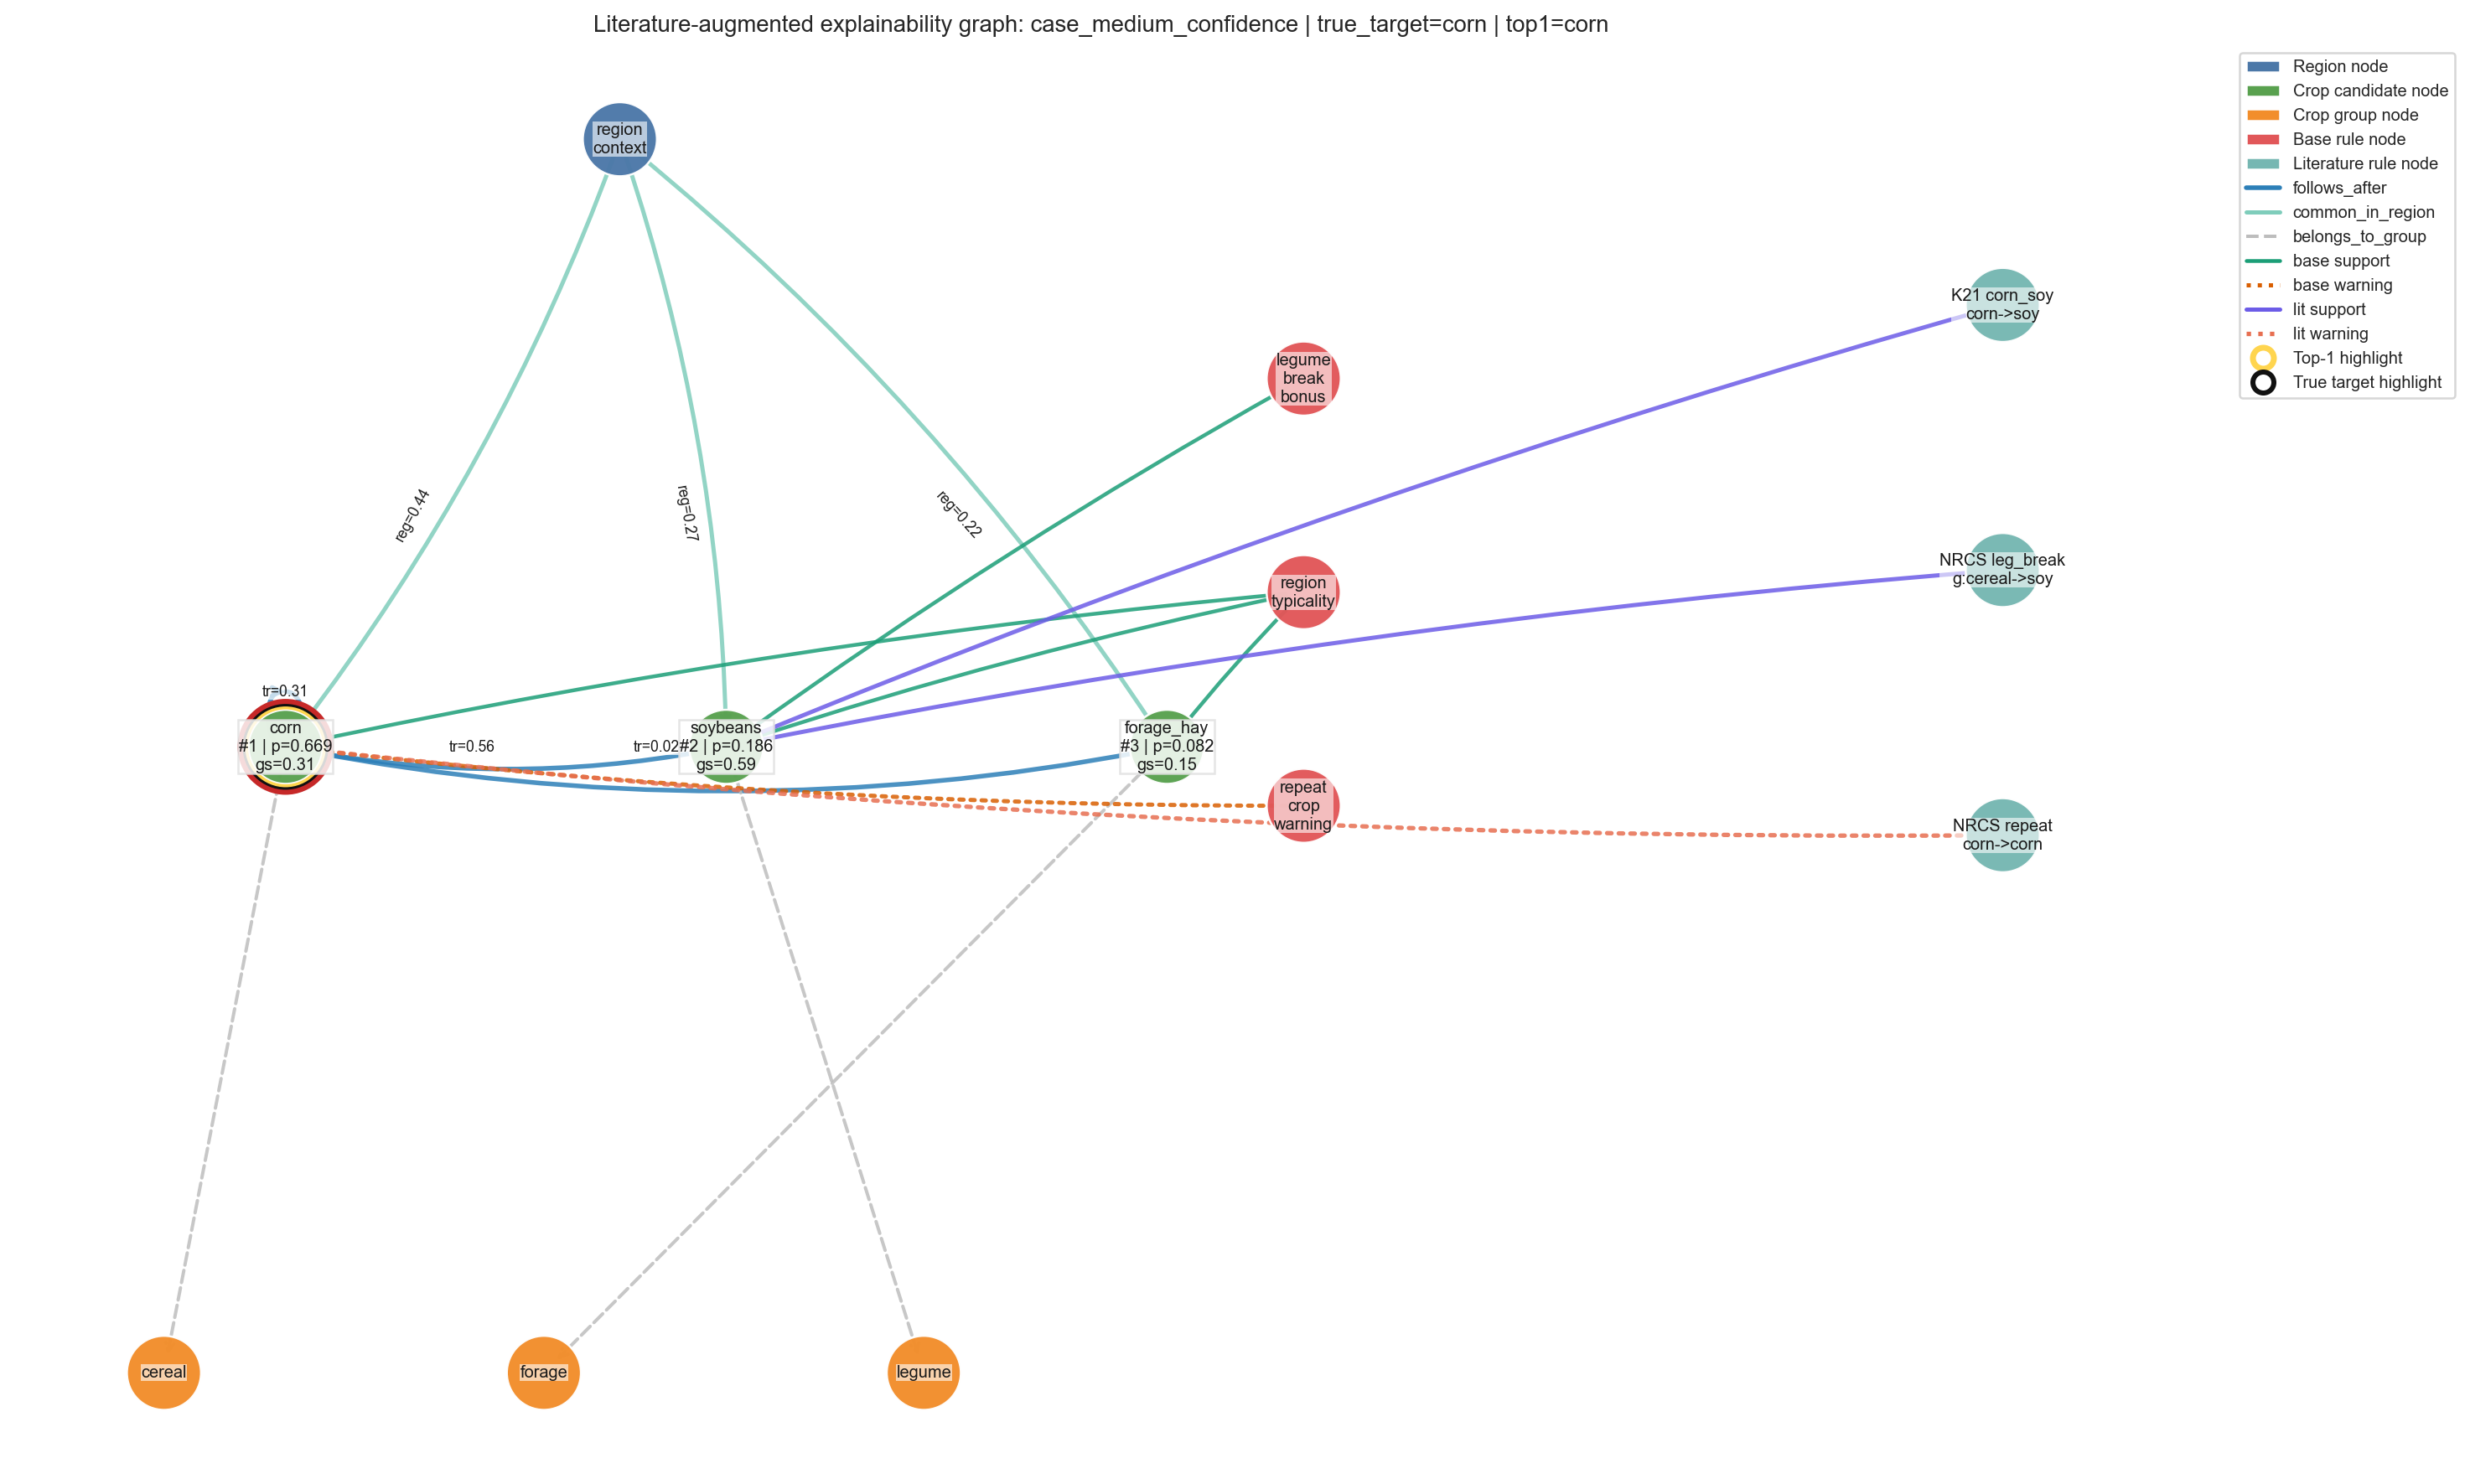

- case_low_confidence: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_low_confidence_literature_graph.png


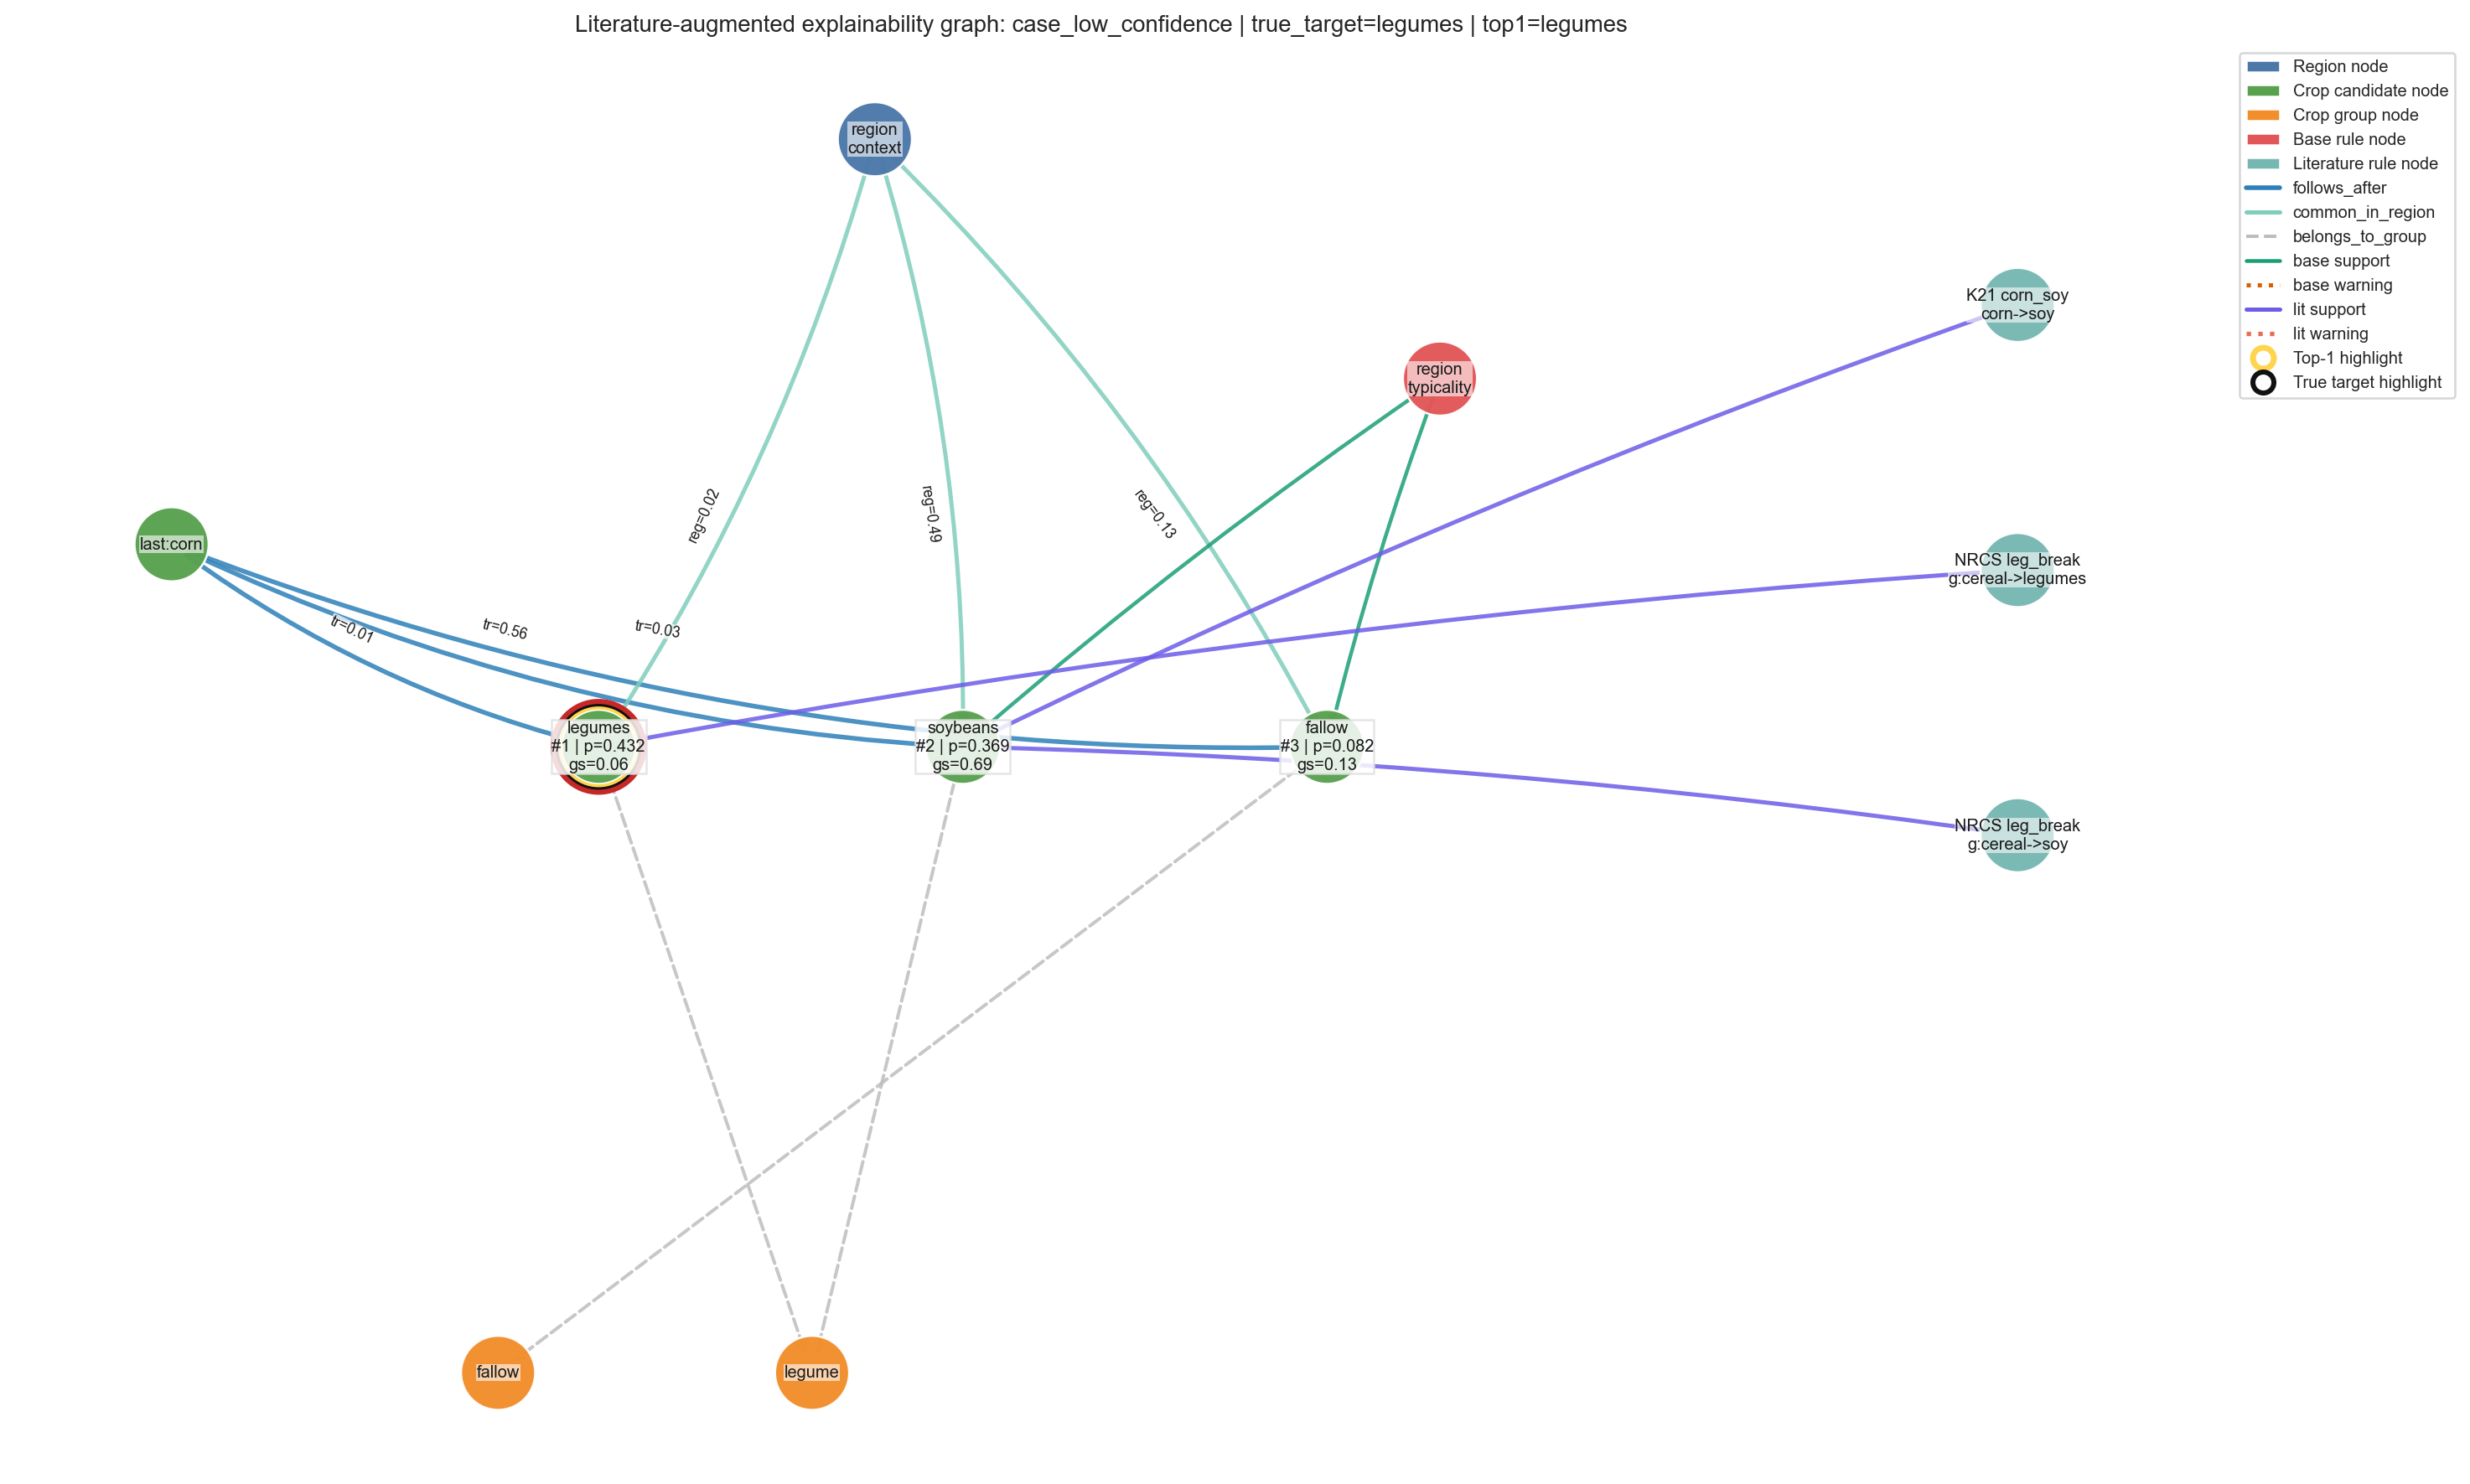

- case_difficult_class: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\case_difficult_class_literature_graph.png


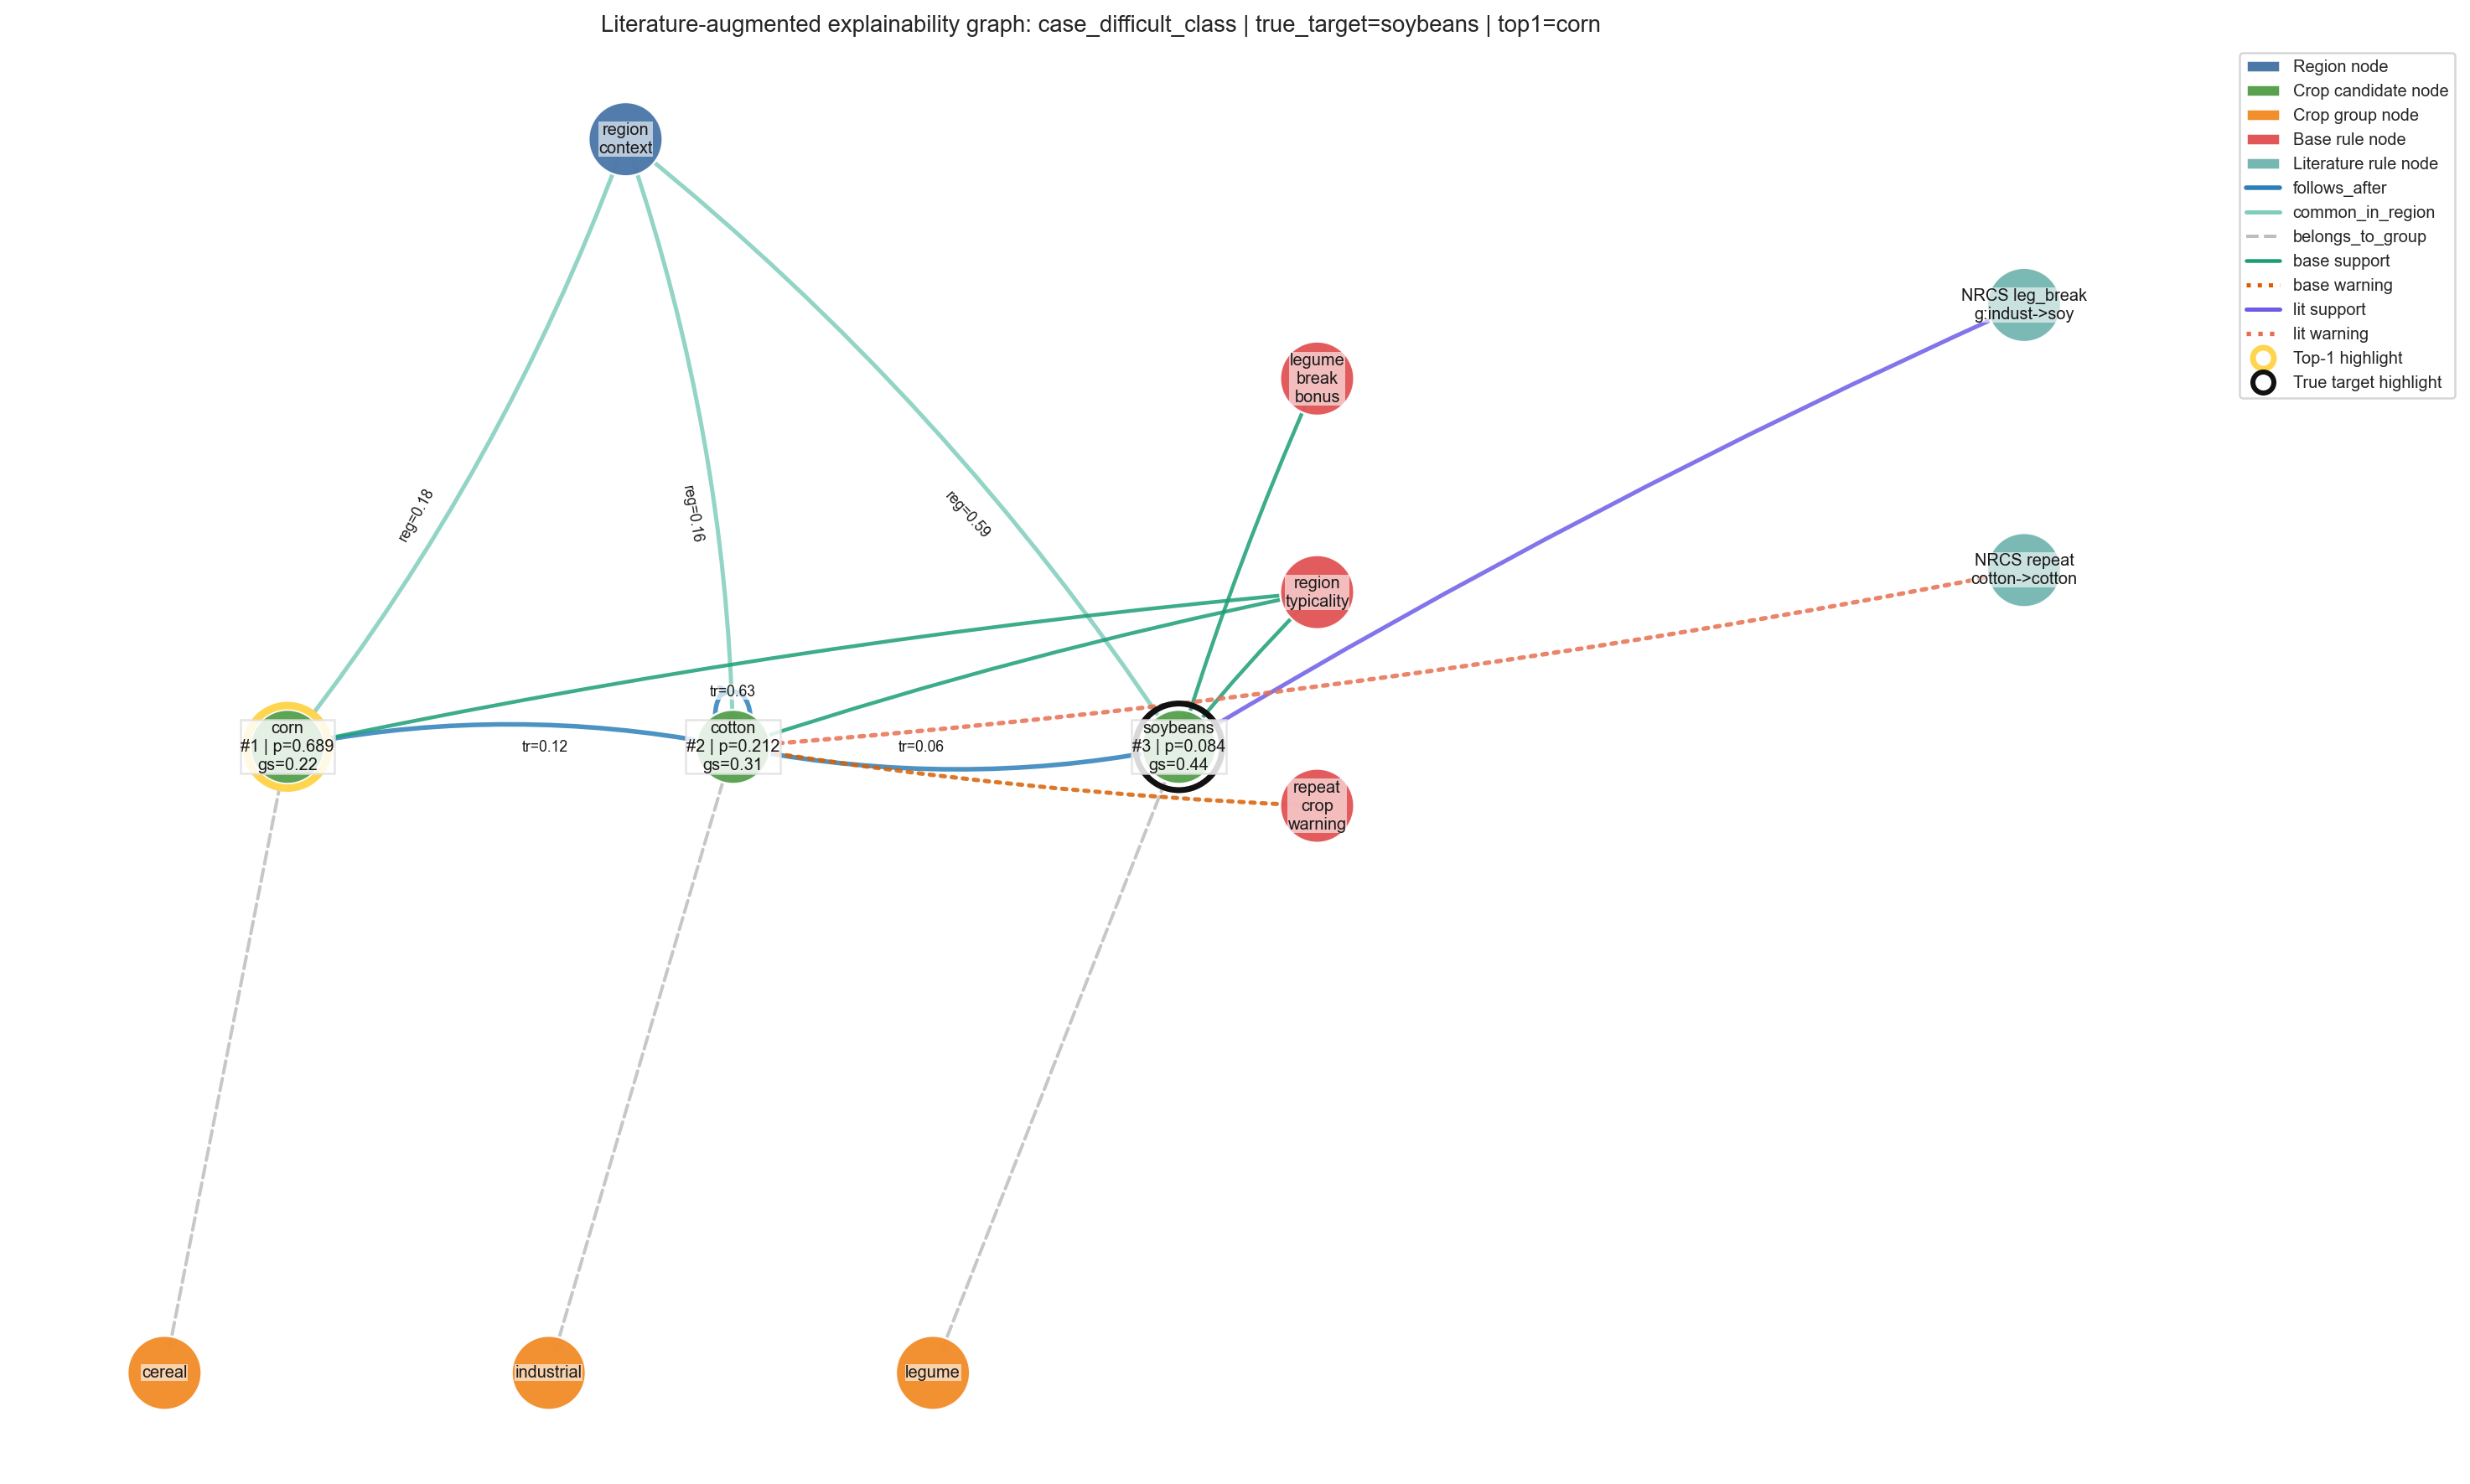

Comparison figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\figures\base_vs_literature_graph_support.png


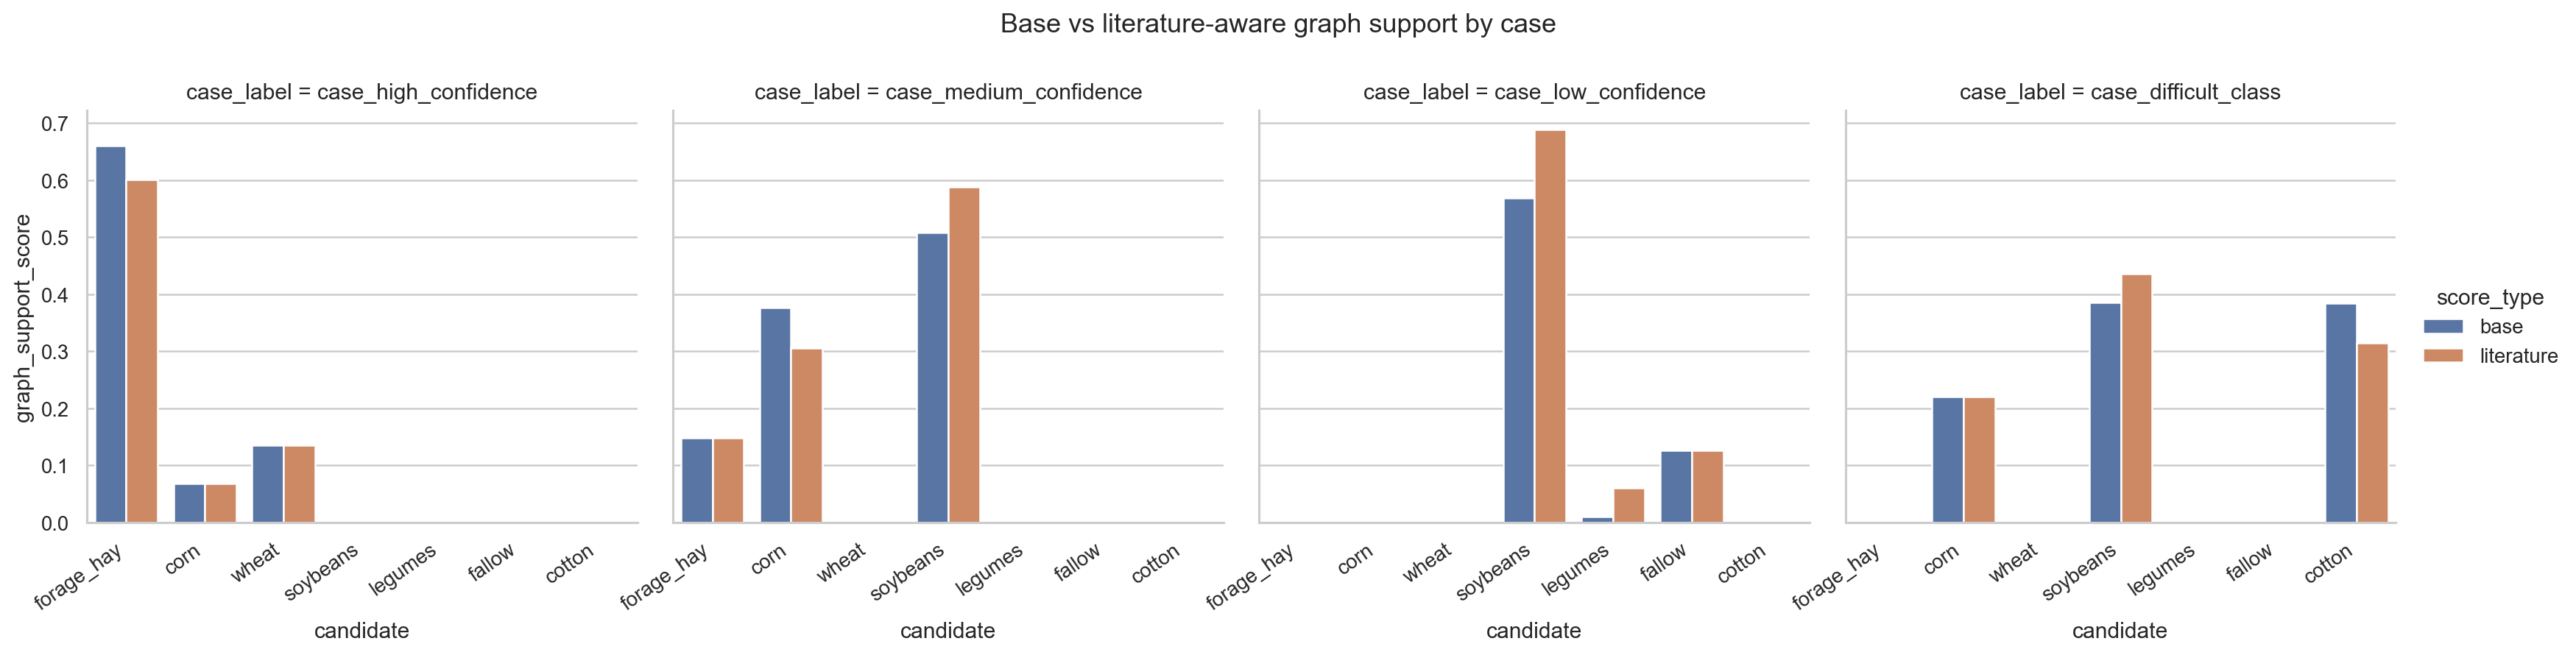

In [7]:
group_values = sorted({g for g in CROP_TO_GROUP.values() if pd.notna(g)})
base_node_ids = set(kg_nodes_df["node_id"])
connected_source_ids = sorted(set(literature_rules_df["source_id"]))

group_nodes = []
for group_name in group_values:
    node_id = f"group_{group_name}"
    if node_id not in base_node_ids:
        group_nodes.append({
            "node_id": node_id,
            "node_type": "CropGroup",
            "name": group_name,
            "display_name": f"group:{group_name}",
            "metadata_json": json.dumps({"group_name": group_name}, ensure_ascii=False),
        })

source_nodes = []
for source_id in connected_source_ids:
    meta = SOURCE_META_BY_ID[source_id]
    source_nodes.append({
        "node_id": f"source_{meta['source_id']}",
        "node_type": "LiteratureSource",
        "name": meta["source_id"],
        "display_name": meta.get("short_label", meta["citation"]),
        "metadata_json": json.dumps(meta, ensure_ascii=False),
    })

rule_nodes = []
for _, rule in literature_rules_df.iterrows():
    rule_nodes.append({
        "node_id": f"litrule_{rule['rule_id']}",
        "node_type": "LiteratureRule",
        "name": rule["rule_id"],
        "display_name": rule["source_title_short"],
        "metadata_json": json.dumps(rule.to_dict(), ensure_ascii=False),
    })

literature_graph_nodes_df = pd.concat(
    [kg_nodes_df, pd.DataFrame(group_nodes), pd.DataFrame(source_nodes), pd.DataFrame(rule_nodes)],
    ignore_index=True,
)


def resolve_context_node(context_value: str) -> str:
    if str(context_value).startswith("group:"):
        return f"group_{str(context_value).split(':', 1)[1]}"
    return f"crop_{context_value}"


literature_edges = []
for _, rule in literature_rules_df.iterrows():
    rule_node_id = f"litrule_{rule['rule_id']}"
    source_node_id = f"source_{rule['source_id']}"
    context_node_id = resolve_context_node(rule["crop_context"])
    candidate_node_id = resolve_context_node(rule["candidate"])
    literature_edges.extend(
        [
            {
                "source_id": source_node_id,
                "target_id": rule_node_id,
                "edge_type": "documents_rule",
                "weight": 1.0,
                "support": 1.0,
                "note": "literature source documents literature rule",
            },
            {
                "source_id": context_node_id,
                "target_id": rule_node_id,
                "edge_type": "literature_context",
                "weight": 1.0,
                "support": 1.0,
                "note": f"literature context from {rule['source_id']}",
            },
            {
                "source_id": rule_node_id,
                "target_id": candidate_node_id,
                "edge_type": f"literature_{normalize_signal_type(rule['signal_type'])}",
                "weight": float(LITERATURE_STRENGTH_WEIGHTS.get(str(rule['strength']).lower(), 0.0)),
                "support": 1.0,
                "note": f"literature evidence from {rule['source_id']}",
            },
        ]
    )

literature_graph_edges_df = pd.concat([kg_edges_df, pd.DataFrame(literature_edges)], ignore_index=True)


def shorten_rule_label(rule_id: str, source_id: str, crop_context: str, candidate: str, signal_type: str) -> str:
    source_tag_map = {
        "nrcs_conservation_crop_rotation_328": "NRCS",
        "kluger_owen_lobell_2021_corn_soy_rotation": "K21",
        "kluger_ditommaso_lobell_2025_precrop_effects": "K25",
        "fusarium_corn_residue_wheat_caution": "FHB",
    }

    crop_alias_map = {
        "corn": "corn",
        "cotton": "cotton",
        "fallow": "fallow",
        "forage_hay": "forage",
        "legumes": "legumes",
        "other_cereals": "oth_cer",
        "sorghum": "sorghum",
        "soybeans": "soy",
        "wheat": "wheat",
    }

    def short_crop_label(value: str) -> str:
        value = str(value)
        if value.startswith("group:"):
            group_name = value.split(":", 1)[1]
            return f"g:{group_name[:6]}"
        return crop_alias_map.get(value, value[:8])

    if "repeat_crop_warning" in rule_id:
        rule_tag = "repeat"
    elif "same_group_saturation_warning" in rule_id:
        rule_tag = "samegrp"
    elif "legume_to_non_legume_support" in rule_id:
        rule_tag = "legume_N"
    elif "legume_break_bonus" in rule_id:
        rule_tag = "leg_break"
    elif "fallow_repeat_warning" in rule_id:
        rule_tag = "fallow_W"
    elif "fallow_to_crop_support" in rule_id:
        rule_tag = "fallow_S"
    elif rule_id == "kluger_corn_to_soybeans_support":
        rule_tag = "corn_soy"
    elif rule_id == "kluger_soybeans_to_corn_support":
        rule_tag = "soy_corn"
    elif rule_id == "fhb_corn_to_wheat_caution":
        rule_tag = "fhb_warn"
    else:
        rule_tag = "lit_rule"

    source_tag = source_tag_map.get(source_id, "LIT")
    ctx = short_crop_label(crop_context)
    cand = short_crop_label(candidate)
    return f"{source_tag} {rule_tag}\n{ctx}->{cand}"


def draw_case_literature_graph(case_label: str, cdf: pd.DataFrame, save_path: Path) -> None:
    cdf = cdf.sort_values(["candidate_rank", "score"]).copy()
    last_crop = str(cdf["last_crop"].iloc[0])
    top1_candidate = str(cdf.loc[cdf["is_model_top1"], "candidate"].iloc[0]) if not cdf.empty else None
    true_target = str(cdf.loc[cdf["is_true_target"], "candidate"].iloc[0]) if cdf["is_true_target"].any() else None
    G = nx.DiGraph()
    region_node = f"region_{case_label}"
    last_crop_node = f"crop_{last_crop}"
    G.add_node(region_node, node_type="Region", label="region\ncontext")
    G.add_node(last_crop_node, node_type="Crop", label=f"last:{last_crop}")

    for row in cdf.to_dict(orient="records"):
        cand = str(row["candidate"])
        cand_node = f"crop_{cand}"
        group_name = str(row["candidate_group_mapped"])
        group_node = f"group_{group_name}"
        cand_label = f"{cand}\n#{int(row['candidate_rank'])} | p={float(row['score']):.3f}\ngs={float(row['literature_graph_support_score']):.2f}"
        G.add_node(
            cand_node,
            node_type="Crop",
            label=cand_label,
            is_candidate=True,
            is_top1=bool(row["is_model_top1"]),
            is_true_target=bool(row["is_true_target"]),
        )
        G.add_node(group_node, node_type="CropGroup", label=group_name)
        G.add_edge(cand_node, group_node, edge_type="belongs_to_group", weight=1.0)
        if not pd.isna(row["transition_prob"]):
            G.add_edge(last_crop_node, cand_node, edge_type="follows_after", weight=float(row["transition_prob"]))
        if not pd.isna(row["region_share"]):
            G.add_edge(region_node, cand_node, edge_type="common_in_region", weight=float(row["region_share"]))

        for flag in list(row["support_flags"]):
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag.replace("_", "\n"))
            G.add_edge(rule_node, cand_node, edge_type="supports_candidate", weight=1.0)
        for flag in list(row["warning_flags"]):
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag.replace("_", "\n"))
            G.add_edge(rule_node, cand_node, edge_type="warns_about_candidate", weight=1.0)

        matched_rule_ids = list(row["literature_support_flags"]) + list(row["literature_warning_flags"])
        for rule_id in matched_rule_ids:
            rule_row = literature_rules_df.loc[literature_rules_df["rule_id"] == rule_id].iloc[0]
            lit_rule_node = f"litrule_{rule_id}"
            G.add_node(
                lit_rule_node,
                node_type="LiteratureRule",
                label=shorten_rule_label(rule_id, rule_row["source_id"], rule_row["crop_context"], rule_row["candidate"], rule_row["signal_type"]),
            )
            lit_edge_type = "literature_supports_candidate" if normalize_signal_type(rule_row["signal_type"]) == "support" else "literature_warns_about_candidate"
            G.add_edge(lit_rule_node, cand_node, edge_type=lit_edge_type, weight=float(LITERATURE_STRENGTH_WEIGHTS.get(str(rule_row["strength"]).lower(), 0.0)))

    pos = {}
    pos[region_node] = (0.0, 2.1)
    pos[last_crop_node] = (-2.8, 1.0)
    candidate_nodes = [f"crop_{str(c)}" for c in cdf["candidate"].astype(str).tolist()]
    for i, node in enumerate(candidate_nodes):
        pos[node] = (-1.1 + i * 1.45, 0.45)
    group_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "CropGroup"])
    for i, node in enumerate(group_nodes):
        pos[node] = (-1.5 + i * 1.25, -1.25)
    base_rule_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "Rule"])
    for i, node in enumerate(base_rule_nodes):
        pos[node] = (2.25, 1.45 - i * 0.58)
    lit_rule_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "LiteratureRule"])
    for i, node in enumerate(lit_rule_nodes):
        pos[node] = (4.55, 1.65 - i * 0.72)
    plt.figure(figsize=(16.5, 10.0))
    labels = {}
    node_colors = []
    for n, d in G.nodes(data=True):
        labels[n] = d.get("label", n)
        ntype = d.get("node_type", "Other")
        if ntype == "Region":
            node_colors.append("#4C78A8")
        elif ntype == "Crop":
            node_colors.append("#59A14F")
        elif ntype == "CropGroup":
            node_colors.append("#F28E2B")
        elif ntype == "Rule":
            node_colors.append("#E15759")
        elif ntype == "LiteratureRule":
            node_colors.append("#76B7B2")
        else:
            node_colors.append("#BDBDBD")
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=list(G.nodes()),
        node_color=node_colors,
        node_size=1250,
        edgecolors="#FFFFFF",
        linewidths=1.0,
        alpha=0.97,
    )
    non_candidate_labels = {n: lbl for n, lbl in labels.items() if n not in set(candidate_nodes)}
    candidate_labels = {n: labels[n] for n in candidate_nodes if n in labels}
    nx.draw_networkx_labels(
        G,
        pos,
        labels=non_candidate_labels,
        font_size=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.60, "pad": 0.2},
    )
    nx.draw_networkx_labels(
        G,
        pos,
        labels=candidate_labels,
        font_size=8,
        bbox={"facecolor": "white", "edgecolor": "#E0E0E0", "alpha": 0.84, "pad": 0.25},
    )
    top1_nodes = [n for n, d in G.nodes(data=True) if d.get("is_top1", False)]
    true_nodes = [n for n, d in G.nodes(data=True) if d.get("is_true_target", False)]
    both_nodes = [n for n in top1_nodes if n in set(true_nodes)]
    if top1_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=top1_nodes, node_color="none", node_size=1550, edgecolors="#FFD54F", linewidths=3.6)
    if true_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=true_nodes, node_color="none", node_size=1710, edgecolors="#111111", linewidths=2.8)
    if both_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=both_nodes, node_color="none", node_size=1880, edgecolors="#C62828", linewidths=2.4)

    edge_groups = {
        "follows_after": {"color": "#2C7FB8", "style": "solid", "width": 2.2, "connectionstyle": "arc3,rad=0.10"},
        "common_in_region": {"color": "#7FCDBB", "style": "solid", "width": 2.0, "connectionstyle": "arc3,rad=-0.08"},
        "belongs_to_group": {"color": "#BDBDBD", "style": "dashed", "width": 1.6, "connectionstyle": "arc3,rad=0.0"},
        "supports_candidate": {"color": "#1B9E77", "style": "solid", "width": 1.8, "connectionstyle": "arc3,rad=0.03"},
        "warns_about_candidate": {"color": "#D95F02", "style": "dotted", "width": 2.0, "connectionstyle": "arc3,rad=-0.03"},
        "documents_rule": {"color": "#9C6DB0", "style": "solid", "width": 1.4, "connectionstyle": "arc3,rad=0.0"},
        "literature_supports_candidate": {"color": "#6C5CE7", "style": "solid", "width": 2.0, "connectionstyle": "arc3,rad=0.03"},
        "literature_warns_about_candidate": {"color": "#E76F51", "style": "dotted", "width": 2.1, "connectionstyle": "arc3,rad=-0.03"},
    }
    for edge_type, style in edge_groups.items():
        edgelist = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == edge_type]
        if edgelist:
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=edgelist,
                arrows=True,
                arrowstyle="->",
                edge_color=style["color"],
                style=style["style"],
                width=style["width"],
                alpha=0.85,
                connectionstyle=style["connectionstyle"],
            )
    follows_labels = {}
    region_labels = {}
    for u, v, d in G.edges(data=True):
        et = d.get("edge_type", "")
        w = d.get("weight")
        if w is None:
            continue
        if et == "follows_after":
            follows_labels[(u, v)] = f"tr={float(w):.2f}"
        elif et == "common_in_region":
            region_labels[(u, v)] = f"reg={float(w):.2f}"
    label_box = {"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.15}
    if follows_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=follows_labels, font_size=7, label_pos=0.42, bbox=label_box, rotate=True)
    if region_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=region_labels, font_size=7, label_pos=0.62, bbox=label_box, rotate=True)
    legend_handles = [
        Patch(facecolor="#4C78A8", edgecolor="#FFFFFF", label="Region node"),
        Patch(facecolor="#59A14F", edgecolor="#FFFFFF", label="Crop candidate node"),
        Patch(facecolor="#F28E2B", edgecolor="#FFFFFF", label="Crop group node"),
        Patch(facecolor="#E15759", edgecolor="#FFFFFF", label="Base rule node"),
        Patch(facecolor="#76B7B2", edgecolor="#FFFFFF", label="Literature rule node"),
        Line2D([0], [0], color="#2C7FB8", lw=2.2, linestyle="solid", label="follows_after"),
        Line2D([0], [0], color="#7FCDBB", lw=2.0, linestyle="solid", label="common_in_region"),
        Line2D([0], [0], color="#BDBDBD", lw=1.6, linestyle="--", label="belongs_to_group"),
        Line2D([0], [0], color="#1B9E77", lw=1.8, linestyle="solid", label="base support"),
        Line2D([0], [0], color="#D95F02", lw=2.0, linestyle=":", label="base warning"),
        Line2D([0], [0], color="#6C5CE7", lw=2.0, linestyle="solid", label="lit support"),
        Line2D([0], [0], color="#E76F51", lw=2.1, linestyle=":", label="lit warning"),
        Line2D([0], [0], marker="o", markersize=10, markerfacecolor="white", markeredgecolor="#FFD54F", markeredgewidth=2.8, lw=0, label="Top-1 highlight"),
        Line2D([0], [0], marker="o", markersize=10, markerfacecolor="white", markeredgecolor="#111111", markeredgewidth=2.4, lw=0, label="True target highlight"),
    ]
    plt.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True, fontsize=8)
    plt.title(f"Literature-augmented explainability graph: {case_label} | true_target={true_target} | top1={top1_candidate}", fontsize=11)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close()


case_figure_paths = []
for case_label, cdf in literature_augmented_case_explanations_df.groupby("case_label", sort=False):
    fig_path = FIGURES_DIR / f"{case_label}_literature_graph.png"
    draw_case_literature_graph(case_label, cdf, fig_path)
    case_figure_paths.append((case_label, fig_path))

plot_df = comparison_df.melt(
    id_vars=["case_label", "candidate"],
    value_vars=["base_graph_support_score", "literature_graph_support_score"],
    var_name="score_type",
    value_name="graph_support_score",
)
plot_df["score_type"] = plot_df["score_type"].map(
    {
        "base_graph_support_score": "base",
        "literature_graph_support_score": "literature",
    }
)

g = sns.catplot(
    data=plot_df,
    x="candidate",
    y="graph_support_score",
    hue="score_type",
    col="case_label",
    kind="bar",
    sharey=True,
    height=4.6,
    aspect=1.0,
)
g.set_xticklabels(rotation=35, ha="right")
g.figure.subplots_adjust(top=0.82)
g.figure.suptitle("Base vs literature-aware graph support by case")
comparison_figure_path = FIGURES_DIR / "base_vs_literature_graph_support.png"
g.savefig(comparison_figure_path, dpi=180, bbox_inches="tight")
plt.close(g.figure)

literature_augmented_case_explanations_df.to_csv(RESULTS_DIR / "literature_augmented_case_explanations.csv", index=False)
literature_augmented_case_summary_df.to_csv(RESULTS_DIR / "literature_augmented_case_summary.csv", index=False)
comparison_df.to_csv(RESULTS_DIR / "literature_vs_base_case_comparison.csv", index=False)
literature_graph_nodes_df.to_csv(RESULTS_DIR / "literature_graph_nodes.csv", index=False)
literature_graph_edges_df.to_csv(RESULTS_DIR / "literature_graph_edges.csv", index=False)

run_summary = json.loads(run_summary_df.to_json(orient="records"))[0]
run_meta = {
    "base_stage": "09_knowledge_graph_explainability",
    "cases_count": int(literature_augmented_case_summary_df["case_label"].nunique()),
    "base_case_rows": int(len(case_explanations_df)),
    "literature_rules_count": int(len(literature_rules_df)),
    "literature_sources_count": int(len(SOURCE_META)),
    "source_ids": sorted(SOURCE_META_BY_ID),
    "graph_source_ids": connected_source_ids,
    "nodes_count": int(len(literature_graph_nodes_df)),
    "edges_count": int(len(literature_graph_edges_df)),
    "alignment_distribution": literature_augmented_case_summary_df["literature_top1_graph_alignment"].value_counts(dropna=False).to_dict(),
    "triggered_rule_ids_unique": triggered_rule_ids_unique,
    "run_summary": run_summary,
    "input_run_meta": base_run_meta,
}
with (RESULTS_DIR / "run_meta.json").open("w", encoding="utf-8") as f:
    json.dump(run_meta, f, ensure_ascii=False, indent=2)

print("Saved literature-aware outputs to:", RESULTS_DIR)
display(literature_augmented_case_summary_df)
print("Machine-readable run summary (persisted in run_meta.json):")
display(run_summary_df)

print("Inline case-study figures:")
for case_label, fig_path in case_figure_paths:
    print(f"- {case_label}: {fig_path}")
    ipy_display(IPImage(filename=str(fig_path)))

print("Comparison figure:", comparison_figure_path)
ipy_display(IPImage(filename=str(comparison_figure_path)))


In [8]:
alignment_view = literature_augmented_case_summary_df[
    [
        "case_label",
        "base_top1_graph_alignment",
        "literature_top1_graph_alignment",
        "alignment_transition",
        "alignment_changed",
        "n_triggered_literature_rules",
        "best_literature_candidate",
        "graph_support_gap_best_minus_top1_literature",
    ]
].copy()

delta_role_df = (
    comparison_df.assign(candidate_role=np.where(comparison_df["is_model_top1"], "model_top1", "non_top1"))
    .groupby("candidate_role", as_index=False)["delta_graph_support_score"]
    .mean()
)
repeat_rows_view = comparison_df.loc[
    comparison_df["is_exact_repeat_candidate_row"],
    [
        "case_label",
        "candidate",
        "has_direct_repeat_warning",
        "direct_repeat_warning_rule_ids",
        "skipped_same_group_saturation_rule_ids",
        "literature_warning_flags",
        "delta_graph_support_score",
    ],
].copy()
changed_cases = alignment_view.loc[alignment_view["alignment_changed"]].copy()
comparison_csv_path = RESULTS_DIR / "literature_vs_base_case_comparison.csv"
run_summary = run_summary_df.iloc[0].to_dict()

analysis_lines = [
    "## Анализ результатов literature-aware graph",
    "",
    "Ниже используются пересчитанные таблицы `literature_augmented_case_summary_df`, `comparison_df` и сохраненный файл `literature_vs_base_case_comparison.csv`, поэтому выводы в этом разделе зависят от фактического результата текущего запуска stage 12.",
    "",
    f"- Число case studies в `literature_augmented_case_summary_df`: {len(literature_augmented_case_summary_df)}.",
    f"- Число candidate-rows в `comparison_df`: {len(comparison_df)}.",
    f"- Путь к сохраненному сравнению: `{comparison_csv_path}`.",
    f"- Exact repeat candidate rows: {int(run_summary['exact_repeat_candidate_rows_count'])}.",
    f"- Same-group saturation warnings skipped because of direct repeat warning: {int(run_summary['skipped_same_group_saturation_due_to_exact_repeat_warning_count'])}.",
    f"- Total triggered literature-rule hits after filtering: {int(run_summary['total_triggered_rule_hits_count'])}.",
]
if changed_cases.empty:
    analysis_lines.append("- В текущем пересчете ни у одного из выбранных кейсов не изменилась итоговая категория case-level alignment.")
else:
    changed_list = ", ".join(
        f"{row.case_label} ({row.alignment_transition})"
        for row in changed_cases.itertuples(index=False)
    )
    analysis_lines.append(f"- В текущем пересчете changed alignment category observed for: {changed_list}.")
analysis_lines.extend(
    [
        "",
        "Same-group saturation is skipped when exact repeat warning is triggered to avoid double-counting; exact crop repetition is treated as the more specific warning signal.",
        "Repeated `forage_hay` is treated as weak warning because forage/perennial/high-biomass classes may have a different agronomic role than annual row-crop repeats.",
        "Literature layer changes interpretation-level support, not model probabilities or recommendation ranking.",
        "",
        "На выбранных case studies literature rules изменяют interpretation-level support отдельных кандидатов; это не является оценкой предиктивного качества модели и не меняет shortlist или вероятности CatBoost.",
        "",
        "Средние candidate-level дельты по ролям приведены ниже: отдельно для model top-1 и для остальных shortlist-кандидатов. Для интерпретации case-level alignment нужно смотреть `alignment_transition` и `graph_support_gap_best_minus_top1_literature` в `literature_augmented_case_summary_df`.",
    ]
)

ipy_display(IPMarkdown("\n".join(analysis_lines)))
display(alignment_view)
display(delta_role_df)
display(repeat_rows_view)
display(comparison_df)


## Анализ результатов literature-aware graph

Ниже используются пересчитанные таблицы `literature_augmented_case_summary_df`, `comparison_df` и сохраненный файл `literature_vs_base_case_comparison.csv`, поэтому выводы в этом разделе зависят от фактического результата текущего запуска stage 12.

- Число case studies в `literature_augmented_case_summary_df`: 4.
- Число candidate-rows в `comparison_df`: 12.
- Путь к сохраненному сравнению: `C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\literature_graph\literature_vs_base_case_comparison.csv`.
- Exact repeat candidate rows: 3.
- Same-group saturation warnings skipped because of direct repeat warning: 3.
- Total triggered literature-rule hits after filtering: 9.
- В текущем пересчете ни у одного из выбранных кейсов не изменилась итоговая категория case-level alignment.

Same-group saturation is skipped when exact repeat warning is triggered to avoid double-counting; exact crop repetition is treated as the more specific warning signal.
Repeated `forage_hay` is treated as weak warning because forage/perennial/high-biomass classes may have a different agronomic role than annual row-crop repeats.
Literature layer changes interpretation-level support, not model probabilities or recommendation ranking.

На выбранных case studies literature rules изменяют interpretation-level support отдельных кандидатов; это не является оценкой предиктивного качества модели и не меняет shortlist или вероятности CatBoost.

Средние candidate-level дельты по ролям приведены ниже: отдельно для model top-1 и для остальных shortlist-кандидатов. Для интерпретации case-level alignment нужно смотреть `alignment_transition` и `graph_support_gap_best_minus_top1_literature` в `literature_augmented_case_summary_df`.

,case_label,base_top1_graph_alignment,literature_top1_graph_alignment,alignment_transition,alignment_changed,n_triggered_literature_rules,best_literature_candidate,graph_support_gap_best_minus_top1_literature
0,case_high_confidence,strong,strong,strong -> strong,False,1,forage_hay,0.000000
1,case_medium_confidence,weak,weak,weak -> weak,False,3,soybeans,0.282135
2,case_low_confidence,weak,weak,weak -> weak,False,3,soybeans,0.627889
3,case_difficult_class,weak,weak,weak -> weak,False,2,soybeans,0.216319


,candidate_role,delta_graph_support_score
0,model_top1,-0.0200
1,non_top1,0.0225


,case_label,candidate,has_direct_repeat_warning,direct_repeat_warning_rule_ids,skipped_same_group_saturation_rule_ids,literature_warning_flags,delta_graph_support_score
0,case_high_confidence,forage_hay,True,[nrcs_repeat_crop_warning_forage_hay],[nrcs_same_group_saturation_warning_forage],[nrcs_repeat_crop_warning_forage_hay],-0.06
3,case_medium_confidence,corn,True,[nrcs_repeat_crop_warning_corn],[nrcs_same_group_saturation_warning_cereal],[nrcs_repeat_crop_warning_corn],-0.07
10,case_difficult_class,cotton,True,[nrcs_repeat_crop_warning_cotton],[nrcs_same_group_saturation_warning_industrial],[nrcs_repeat_crop_warning_cotton],-0.07


,case_label,candidate,candidate_rank,is_model_top1,is_true_target,base_graph_support_score,base_graph_support_level,literature_graph_support_score,literature_graph_support_level,delta_graph_support_score,top1_graph_alignment,literature_support_flags,literature_warning_flags,n_literature_rules_matched,matched_literature_rule_ids,is_exact_repeat_candidate_row,has_direct_repeat_warning,direct_repeat_warning_rule_ids,skipped_same_group_saturation_rule_ids,literature_evidence_summary
0,case_high_confidence,forage_hay,1,True,True,0.660545,strong,0.600545,moderate,-6.000000e-02,strong,[],[nrcs_repeat_crop_warning_forage_hay],1,[nrcs_repeat_crop_warning_forage_hay],True,True,[nrcs_repeat_crop_warning_forage_hay],[nrcs_same_group_saturation_warning_forage],[nrcs_conservation_crop_rotation_328] NRCS CPS...
1,case_high_confidence,corn,2,False,False,0.067884,weak,0.067884,weak,2.775558e-17,strong,[],[],0,[],False,False,[],[],
2,case_high_confidence,wheat,3,False,False,0.135650,weak,0.135650,weak,5.551115e-17,strong,[],[],0,[],False,False,[],[],
3,case_medium_confidence,corn,1,True,True,0.375989,moderate,0.305989,weak,-7.000000e-02,weak,[],[nrcs_repeat_crop_warning_corn],1,[nrcs_repeat_crop_warning_corn],True,True,[nrcs_repeat_crop_warning_corn],[nrcs_same_group_saturation_warning_cereal],[nrcs_conservation_crop_rotation_328] NRCS CPS...
4,case_medium_confidence,soybeans,2,False,False,0.508123,moderate,0.588123,moderate,8.000000e-02,weak,[nrcs_legume_break_bonus_soybeans_after_cereal...,[],2,"[kluger_corn_to_soybeans_support, nrcs_legume_...",False,False,[],[],[nrcs_conservation_crop_rotation_328] NRCS CPS...
5,case_medium_confidence,forage_hay,3,False,False,0.148390,weak,0.148390,weak,-5.551115e-17,weak,[],[],0,[],False,False,[],[],
6,case_low_confidence,legumes,1,True,True,0.010571,weak,0.060571,weak,5.000000e-02,weak,[nrcs_legume_break_bonus_legumes_after_cereal],[],1,[nrcs_legume_break_bonus_legumes_after_cereal],False,False,[],[],[nrcs_conservation_crop_rotation_328] NRCS CPS...
7,case_low_confidence,soybeans,2,False,False,0.568460,moderate,0.688460,strong,1.200000e-01,weak,[nrcs_legume_break_bonus_soybeans_after_cereal...,[],2,"[kluger_corn_to_soybeans_support, nrcs_legume_...",False,False,[],[],[nrcs_conservation_crop_rotation_328] NRCS CPS...
8,case_low_confidence,fallow,3,False,False,0.125709,weak,0.125709,weak,0.000000e+00,weak,[],[],0,[],False,False,[],[],
9,case_difficult_class,corn,1,True,False,0.219969,weak,0.219969,weak,-5.551115e-17,weak,[],[],0,[],False,False,[],[],


## Краткие выводы по этапу

- Stage `12` остается отдельным интерпретационным слоем поверх готовых case explanations из `09` и не меняет модель, shortlist, model probabilities или ranking кандидатов.
- Новый literature-aware graph использует US/international external agronomic evidence, согласованное с географией исходного датасета USDA NASS CSB/CDL.
- Stage `12` пересчитывает только interpretation-level outputs: literature support/warning flags, `literature_graph_support_score`, `delta_graph_support_score`, case-level alignment comparison и literature graph nodes/edges.
- Same-group saturation warning пропускается, если уже сработал exact repeat warning, чтобы не было двойного штрафа за один и тот же смысл.
- Повтор `forage_hay` трактуется как weak warning, потому что агрегированный forage/perennial/high-biomass класс может быть менее проблемным, чем повтор annual row-crop.
- Старые cotton-specific zonal rules удалены; для `cotton` в этой версии сохранены только общие repeat/group warnings.
- Правила остаются explainability evidence, а не универсальными агрономическими предписаниями и не механизмом агрономической оптимизации.
